# Analyse des pertes post-récolte de l'arachide et de leurs impacts socio-économiques

**Zone d'étude :** communes de Nioro Alassane Tall, Keur Samba Guèye et Keur Saloum Diané (bassin arachidier, Sénégal)
**Sources :** (1) enquête KoboToolbox auprès de 195 producteurs ; (2) fiche de relevé de poids (suivi de stocks de gousses et de graines décortiquées sur 3 pesées).
**Environnement :** Python 3 · pandas · scipy · statsmodels · scikit-learn · matplotlib/seaborn (notebook exécutable dans Jupyter ou VS Code).

---
## ÉTAPE 1 — Compréhension métier

### Contexte
L'arachide est la principale culture de rente du bassin arachidier sénégalais. Entre la récolte et la commercialisation, une partie de la production disparaît (séchage, battage, stockage) ou se dégrade (moisissures, insectes, rongeurs). Ces pertes post-récolte réduisent le revenu des ménages, la disponibilité alimentaire pendant la soudure et la qualité (donc le prix) du produit vendu.

### Objectifs de l'étude
1. **Quantifier** les pertes post-récolte (perçues et mesurées) aux différentes étapes : séchage, battage, stockage.
2. **Identifier les déterminants** des pertes de stockage : mode et lieu de stockage, traitement, durée, quantité stockée, profil du producteur.
3. **Évaluer les impacts socio-économiques** : valeur monétaire des pertes, couverture alimentaire, achats compensatoires, charge de travail, conséquences sociales.
4. **Segmenter** les producteurs en profils homogènes pour cibler les interventions.
5. **Formuler des recommandations** techniques, agronomiques, économiques et stratégiques exploitables.

### Enjeux
- Sécurité alimentaire des ménages (soudure).
- Revenu et endettement des producteurs (achats compensatoires financés par emprunt).
- Qualité sanitaire (moisissures → risque aflatoxines) et prix de vente.
- Charge de travail des femmes (tri, surveillance).
- Orientation des investissements (magasins, fûts, produits de traitement, formation).

### Hypothèses à tester (H0 = absence d'effet)
| Code | Hypothèse |
|---|---|
| H1 | Les pertes mesurées sont plus élevées sur les graines décortiquées que sur les gousses. |
| H2 | Le moyen de stockage hermétique (bidon / fût) réduit les pertes par rapport aux sacs. |
| H3 | Le traitement chimique du stock réduit les pertes mesurées. |
| H4 | Les pertes varient significativement selon la commune / le village. |
| H5 | La valeur monétaire déclarée des pertes croît avec la production et la quantité stockée. |
| H6 | Les producteurs déclarant des pertes de stockage sont plus exposés à l'insécurité alimentaire (période de couverture non assurée). |
| H7 | La formation reçue et le niveau d'instruction sont associés à une moindre déclaration de pertes. |
| H8 | Le rendement dépend de la superficie (économies/déséconomies d'échelle). |

### KPI retenus
- Taux de perte mesuré (%) = (poids initial − dernier poids) / poids initial × 100, par nature (gousses / décortiqué).
- % de producteurs déclarant des pertes de stockage ; % jugeant les pertes au séchage « importantes ».
- Valeur monétaire moyenne des pertes de stock (FCFA) et son ratio sur la production.
- Rendement (kg/ha), production, quantité stockée, part vendue / autoconsommée / semence.
- % de ménages sans couverture alimentaire annuelle ; % ayant recours à l'emprunt.

### Variables cibles et explicatives
- **Cibles :** taux de perte mesuré (fiche de relevé) ; déclaration de pertes de stockage (oui/non) ; valeur des pertes (FCFA) ; couverture alimentaire (oui/non) ; rendement.
- **Explicatives :** commune, village, âge, sexe, instruction, formation, superficie, production, quantité stockée, durée de stockage, lieu et mode de stockage, traitement (nature, fréquence), ennemis des stocks, mode de battage, problèmes au séchage.

### Questions d'analyse
1. Quel est le niveau réel des pertes en stock et où se concentrent-elles (commune, village, nature du produit) ?
2. Quels facteurs de stockage sont associés aux pertes les plus faibles ?
3. Combien les pertes coûtent-elles aux ménages et comment ces coûts sont-ils financés ?
4. Qui sont les producteurs les plus vulnérables et quel profil d'intervention leur correspond ?

## Configuration de l'environnement

In [1]:
import warnings, re, unicodedata, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
# (backend inline par défaut sous Jupyter)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", palette="viridis", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110

# Chemins (le notebook est exécuté depuis le dossier `notebooks/`)
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW = os.path.join(ROOT, "data", "raw")
CLEAN = os.path.join(ROOT, "data", "clean")
FIG = os.path.join(ROOT, "figures")
os.makedirs(CLEAN, exist_ok=True); os.makedirs(FIG, exist_ok=True)

F_ENQ = os.path.join(RAW, "enquete_arachide_kobo.xlsx")
F_POIDS = os.path.join(RAW, "fiche_releve_poids.xlsx")

def savefig(name):
    """Sauvegarde la figure courante dans figures/ (PNG 150 dpi)."""
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, f"{name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

def norm_txt(s):
    """Normalise un texte : minuscules, sans accents, espaces multiples réduits."""
    if pd.isna(s):
        return np.nan
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return re.sub(r"\s+", " ", s).strip().lower()

---
## ÉTAPE 2 — Audit complet des données

### 2.1 Fichier 1 : enquête producteurs (export KoboToolbox « labels »)

In [2]:
raw = pd.read_excel(F_ENQ)
print(f"Dimensions brutes : {raw.shape[0]} lignes × {raw.shape[1]} colonnes")

# Typologie des colonnes de l'export Kobo
empty_cols = [c for c in raw.columns if raw[c].notna().sum() == 0]
dummy_cols = [c for c in raw.columns if "/" in c and c not in empty_cols]
meta_cols = [c for c in raw.columns if c.startswith("_") or c in ("start", "end", "meta/rootUuid")]
print(f"Colonnes entièrement vides (questions non déployées / anciennes versions) : {len(empty_cols)}")
print(f"Colonnes binaires issues des choix multiples (format 'question/modalité') : {len(dummy_cols)}")
print(f"Colonnes de métadonnées Kobo : {len(meta_cols)}")
print(f"Colonnes substantives restantes : {raw.shape[1] - len(empty_cols) - len(dummy_cols) - len(meta_cols)}")

Dimensions brutes : 195 lignes × 193 colonnes
Colonnes entièrement vides (questions non déployées / anciennes versions) : 53
Colonnes binaires issues des choix multiples (format 'question/modalité') : 82
Colonnes de métadonnées Kobo : 13
Colonnes substantives restantes : 45


In [3]:
# Rapport de complétude par variable substantive
subst = [c for c in raw.columns if c not in empty_cols + dummy_cols + meta_cols]
audit = pd.DataFrame({
    "variable": subst,
    "type": [str(raw[c].dtype) for c in subst],
    "n_renseigne": [raw[c].notna().sum() for c in subst],
    "pct_manquant": [round(100 * raw[c].isna().mean(), 1) for c in subst],
    "n_modalites": [raw[c].nunique() for c in subst],
})
audit

,variable,type,n_renseigne,pct_manquant,n_modalites
0,Analyse des pertes post récoltes sur l'arachid...,str,194,0.5,9
1,1. INFORMATION SOCIO DEMOGRAPHIQUES,str,2,99.0,2
2,1.1. Prénom et Nom:,str,195,0.0,183
3,1.2. Sexe,str,195,0.0,2
4,1.3. Age,int64,195,0.0,48
5,1.4. Commune :,str,195,0.0,3
6,1.5. Village :,str,195,0.0,15
7,1.6. Téléphone,float64,176,9.7,176
8,1.7. Niveau d'instruction,str,195,0.0,8
9,1.8. Activité dans la chaine de valeur,str,195,0.0,2


**Constats de l'audit (enquête)** :
- Export Kobo « all versions » : **45 colonnes vides** proviennent d'une ancienne version du formulaire (questions renommées : 2.4.1 Types/mode de stockage, 3.3.2 avenir des jeunes, Mode de financement…). Elles sont supprimées.
- Les questions à choix multiples sont doublées : une colonne texte concaténée + une colonne 0/1 par modalité. Les colonnes 0/1 sont conservées (exploitables directement), la colonne texte sert de contrôle.
- Variables « libres » très hétérogènes : `Comment avez-vous financé cet achat` (42 graphies pour ~5 modalités), `4.1 Solution d'atténuation` (58 graphies). Elles nécessitent une recodification.
- Modalités avec espaces parasites (« Masculin  », « Coranique  ») → standardisation.
- Les champs « note » du formulaire (2.2, 2.3, 2.4, 3.2, 3.3) sont vides par construction.
- Champ titre : 9 enregistrements portent la mention « à tester » (lots expérimentaux : ail, bidons sans traitement). Ils sont conservés (ce sont de vrais producteurs) mais signalés par un indicateur `lot_test`.

In [4]:
# Doublons : identifiant Kobo unique ? homonymes ?
print("Doublons stricts d'_uuid :", raw["_uuid"].duplicated().sum())
nom_norm = raw["1.1. Prénom et Nom:"].map(norm_txt)
homon = raw[nom_norm.duplicated(keep=False)][["1.1. Prénom et Nom:", "1.5. Village :", "1.3. Age"]].sort_values("1.1. Prénom et Nom:")
print(f"Homonymes (même nom) : {len(homon)} lignes — vérification village/âge :")
homon

Doublons stricts d'_uuid : 0
Homonymes (même nom) : 31 lignes — vérification village/âge :


,1.1. Prénom et Nom:,1.5. Village :,1.3. Age
194,Ablaye Ndiaye,Touba mouride,68
106,Ablaye diba,Ndiayene keur momath,70
125,Ablaye diba,Médina Djikoy,40
26,Ablaye ndiaye,Ndiayene Moussa,66
101,Ablaye ndiaye,Touba mouride,45
107,Aliou konte,Keur Mamath souna,40
176,Aliou konte,Keur Samba nosso,40
165,Babacar Bitey,Passy Nderderleing,48
79,Babacar Gueye,Keur Babou Ndity,56
188,Babacar Gueye,Touba mouride,53


Les homonymes correspondent à des villages **différents** ou des âges différents : ce sont des personnes distinctes (patronymes très fréquents dans la zone : Ndiaye, Gueye, Thiam…). Aucun doublon réel n'est retenu.

In [5]:
# Contrôle des variables numériques : distributions, valeurs aberrantes
num_map = {
    "1.3. Age": "age",
    "Superficie moyenne cultivée ces 04 dernières années": "superficie_ha",
    "Production moyenne annuelle des 04 dernières années en kg, en tonnes ou sacs de 100kg": "production_kg",
    "Pourcentage destiné à la vente": "pct_vente",
    "Pourcentage pour l'autoconsommation": "pct_autoconso",
    "Pourcentage pour la semence": "pct_semence",
    "2.4.3. Quantité de récolte conservée": "qte_stockee_kg",
    "Valeur des pertes de stock": "valeur_pertes_fcfa",
    "Prix d'achat des produits": "prix_achat_fcfa",
}
raw[list(num_map)].rename(columns=num_map).describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
age,195.0,52.8,13.7,25.0,41.5,53.0,64.0,89.0
superficie_ha,195.0,10.7,107.2,1.0,2.0,3.0,4.0,1500.0
production_kg,195.0,2793.4,4824.7,70.0,1000.0,1600.0,2500.0,50000.0
pct_vente,195.0,62.7,16.8,0.0,60.0,70.0,70.0,90.0
pct_autoconso,195.0,20.3,17.4,0.0,10.0,15.0,20.0,100.0
pct_semence,193.0,16.8,6.7,0.0,10.0,20.0,20.0,50.0
qte_stockee_kg,195.0,896.3,1395.6,0.0,400.0,600.0,800.0,15000.0
valeur_pertes_fcfa,146.0,59246.6,53195.6,5000.0,30000.0,50000.0,78750.0,500000.0
prix_achat_fcfa,190.0,1352.6,4132.8,500.0,800.0,1000.0,1000.0,50000.0


In [6]:
# Cohérence : somme des pourcentages d'usage de la production
tot = raw["Pourcentage destiné à la vente"] + raw["Pourcentage pour l'autoconsommation"] + raw["Pourcentage pour la semence"].fillna(0)
print("Somme vente+autoconso+semence :"); print(tot.value_counts().sort_index())

# Rendement implicite et incohérences
rdt = raw["Production moyenne annuelle des 04 dernières années en kg, en tonnes ou sacs de 100kg"] / raw["Superficie moyenne cultivée ces 04 dernières années"]
print("\nRendement implicite (kg/ha) — quantiles :"); print(rdt.quantile([0, .05, .25, .5, .75, .95, 1]).round(0))
print("\nEnregistrements à rendement implausible (>3000 kg/ha) ou superficie >100 ha ou stock > production :")
sus = raw[(rdt > 3000) | (raw["Superficie moyenne cultivée ces 04 dernières années"] > 100) |
          (raw["2.4.3. Quantité de récolte conservée"] > raw["Production moyenne annuelle des 04 dernières années en kg, en tonnes ou sacs de 100kg"])]
sus[["1.1. Prénom et Nom:", "1.5. Village :", "Superficie moyenne cultivée ces 04 dernières années",
     "Production moyenne annuelle des 04 dernières années en kg, en tonnes ou sacs de 100kg", "2.4.3. Quantité de récolte conservée"]]

Somme vente+autoconso+semence :
30.0       1
90.0       2
100.0    190
101.0      1
105.0      1
Name: count, dtype: int64

Rendement implicite (kg/ha) — quantiles :
0.00       0.0
0.05     300.0
0.25     500.0
0.50     700.0
0.75     950.0
0.95    1430.0
1.00    6667.0
dtype: float64

Enregistrements à rendement implausible (>3000 kg/ha) ou superficie >100 ha ou stock > production :


,1.1. Prénom et Nom:,1.5. Village :,Superficie moyenne cultivée ces 04 dernières années,"Production moyenne annuelle des 04 dernières années en kg, en tonnes ou sacs de 100kg",2.4.3. Quantité de récolte conservée
3,Amadou camara,Touba mouride,3,20000,2000
79,Babacar Gueye,Keur Babou Ndity,1500,70,600
142,Keba Gueye,Keur ayib ka,6,30000,10000
145,Mbaye Gueye,Keur ayib ka,10,50000,15000
154,Mouhameth ndiaye,Keur ayib ka,3,15000,3000
155,Omar Drame,Keur ayib ka,3,19000,3800


**Anomalies détectées** :
- 1 enregistrement avec superficie = 1 500 « ha » et production = 70 kg (stock 600 kg > production) : erreur de saisie manifeste (probable inversion / oubli d'unité). Superficie et production sont mises en valeur manquante pour cet enregistrement.
- 5 enregistrements affichent des rendements de 5 000 à 6 700 kg/ha, soit 3 à 5 fois le potentiel agronomique de l'arachide pluviale au Sénégal (1 000 – 2 000 kg/ha). La production a probablement été déclarée dans une autre unité (bottes, sacs) ou la superficie sous-estimée. Ces valeurs sont **plafonnées** pour le calcul de rendement (rendement > 3 000 kg/ha → manquant) tout en conservant la production déclarée dans une variable brute.
- `Prix d'achat des produits` : 188 valeurs entre 500 et 1 500 FCFA (prix au kg de l'arachide achetée) et 2 valeurs à 30 000 / 50 000 (montant total probable). Recodage : valeurs > 5 000 → manquant.
- Pourcentages : 190/195 totalisent 100 % ; 5 cas légèrement différents (90–105 %) → conservés (erreurs d'arrondi), signalés.

### 2.2 Fichier 2 : fiche de relevé de poids (gousses & décortiqué)

Structure semi-tabulaire : lignes de titre de village, lignes producteurs, lignes de formules « taux de perte par village » et « par commune ». La commune n'est écrite que sur la première ligne de son bloc. Un parseur dédié reconstruit un tableau propre.

In [7]:
from openpyxl import load_workbook

def parse_fiche(path, sheet):
    """Transforme une feuille semi-structurée de la fiche de relevé en DataFrame long.
    - propage la commune et le village vers le bas ;
    - ignore les lignes d'agrégats (formules AVERAGE) ;
    - évalue les rares cellules formules ('=4*15')."""
    wb = load_workbook(path, read_only=True, data_only=False)
    ws = wb[sheet]
    rows, commune, village = [], None, None
    for r in ws.iter_rows(min_row=3, values_only=True):
        r = list(r) + [None] * (13 - len(r))
        col_a, col_b, nature = r[0], r[1], r[3]
        if col_a:
            commune = str(col_a).strip()
        if col_b and nature is None and (isinstance(col_b, str) and "taux" not in col_b.lower()):
            village = str(col_b).strip()
            continue
        if isinstance(col_b, str) and "taux" in col_b.lower():
            continue  # ligne d'agrégat
        if nature is None:
            continue
        def val(x):
            if isinstance(x, str) and x.startswith("="):
                return eval(x[1:])  # ex '=4*15'
            return x
        rows.append({
            "commune": commune, "village": village,
            "prenom": (str(col_b) if col_b else "").strip(), "nom": (str(r[2]) if r[2] else "").strip(),
            "nature": str(nature).strip(),
            "poids_initial": val(r[4]), "pesee_1": val(r[5]), "pesee_2": val(r[6]), "pesee_3": val(r[7]),
            "formule_taux": r[8], "type_stockage": r[9], "moyen_stockage": r[10],
            "traitement": r[11], "degats": r[12],
        })
    return pd.DataFrame(rows)

gousses = parse_fiche(F_POIDS, "Gousses")
decort = parse_fiche(F_POIDS, "Decortiqué")
# La cellule commune du 1er bloc est vide dans la feuille Décortiqué : on déduit la commune du village (feuille Gousses)
v2c = gousses.drop_duplicates("village").set_index("village")["commune"]
decort["commune"] = decort["village"].map(v2c)
print("Gousses :", gousses.shape, "| Décortiqué :", decort.shape)
print("\nCommunes × villages (gousses) :")
print(gousses.groupby("commune")["village"].nunique())
decort.head(8)

Gousses : (96, 14) | Décortiqué : (96, 14)

Communes × villages (gousses) :
commune
KEUR SALOUM DIANE      4
Keur Samba Gueye       5
Nioro Alassane Tall    6
Name: village, dtype: int64


,commune,village,prenom,nom,nature,poids_initial,pesee_1,pesee_2,pesee_3,formule_taux,type_stockage,moyen_stockage,traitement,degats
0,KEUR SALOUM DIANE,Keur babou ndity,Amadou,DIALLO,Decortiqué,200,200,200.0,200.0,=((E4-H4)/E4)*100,magasin,Bidons,Ail,NaN
1,KEUR SALOUM DIANE,Keur babou ndity,Cheikh omar,Fall,Decortiqué,200,100,100.0,100.0,=((E5-H5)/E5)*100,magasin,Sac,Chimiques perles,Trouaison
2,KEUR SALOUM DIANE,Keur babou ndity,Saliou,Sall,Decortiqué,200,200,100.0,100.0,=((E6-H6)/E6)*100,magasin,Sac,Chimiques perles,"moississures, trouaison"
3,KEUR SALOUM DIANE,Keur babou ndity,Bass,Diallo,Decortiqué,200,200,200.0,200.0,=((E7-F7)/E7)*100,magasin,Sac,Aucun,NaN
4,KEUR SALOUM DIANE,Thiarene babou,Aladji,Sarr,Decortiqué,150,150,150.0,150.0,=((E10-F10)/E10)*100,magasin,Sac,Chimiques perles,NaN
5,KEUR SALOUM DIANE,Thiarene babou,Bara,Sarr,Decortiqué,300,300,250.0,250.0,=((E11-H11)/E11)*100,magasin,Sac,Chimiques perles,trouaison
6,KEUR SALOUM DIANE,Thiarene babou,Baye dame,Thiam,Decortiqué,700,700,700.0,700.0,=((E12-F12)/E12)*100,magasin,Bidons,Aucun,NaN
7,KEUR SALOUM DIANE,Thiarene babou,Ali,Mangane,Decortiqué,250,250,200.0,200.0,=((E13-H13)/E13)*100,magasin,Sacs,Chimiques perles,NaN


**Constats de l'audit (fiche de relevé)** :
- 96 lots de gousses et 96 lots de graines décortiquées (mêmes producteurs), 3 communes, 15 villages — structure identique à l'enquête.
- **Gousses : une seule pesée** de suivi (colonnes « 2e » et « 3e pesée » vides) ; **décortiqué : 3 pesées** (sauf 2 lots).
- Les formules Excel de taux sont **incohérentes** : pour le décortiqué, 72 lignes calculent la perte sur la 1ʳᵉ pesée (`E-F`) et seulement 24 sur la 3ᵉ (`E-H`), alors que des pertes surviennent entre la 1ʳᵉ et la 3ᵉ pesée ; certaines moyennes de village utilisent `AVERAGE(I23+I24+I25+I26)` (somme, pas moyenne), une inclut l'en-tête, deux omettent un producteur. Le taux de perte est donc **recalculé** ici de façon homogène : perte = (poids initial − dernière pesée disponible) / poids initial.
- Type de stockage constant (« magasin » = pièce de stockage) ; moyens : sac / bidon / fût (« Fus ») / barrique (« Barigo ») avec graphies variables ; traitement : perles chimiques (phosphure d'aluminium), poudre, ail, aucun.
- Poids initiaux très dispersés (25 kg à 10 000 kg) : un lot de 10 t (gousses) / 8 t (décortiqué) est un opérateur/gros stockeur — signalé pour les analyses pondérées.

In [8]:
# Vérification de l'incohérence des formules d'origine
for name, d in [("Gousses", gousses), ("Décortiqué", decort)]:
    ref = d["formule_taux"].astype(str).str.extract(r"-([A-Z])\d+\)")[0]
    print(name, "— colonne de pesée utilisée dans la formule d'origine :", ref.value_counts().to_dict())

Gousses — colonne de pesée utilisée dans la formule d'origine : {'F': 96}
Décortiqué — colonne de pesée utilisée dans la formule d'origine : {'F': 72, 'H': 24}


---
## ÉTAPE 3 — Nettoyage et préparation

Chaque transformation est justifiée en commentaire. Résultat : `enq` (195 producteurs × variables recodées) et `poids` (128 lots).

In [9]:
df = raw.drop(columns=empty_cols).copy()

# --- Identification & socio-démographie -------------------------------------------------
enq = pd.DataFrame({
    "id": df["_id"],
    "nom": df["1.1. Prénom et Nom:"].str.strip(),
    "sexe": df["1.2. Sexe"].str.strip().replace({"Feminin": "Féminin"}),
    "age": df["1.3. Age"],
    "commune": df["1.4. Commune : "].str.strip().replace({"Keur saloum Diane": "Keur Saloum Diané", "Keur Samba Gueye": "Keur Samba Guèye"}),
    "village": df["1.5. Village :"].str.strip(),
    "instruction": df["1.7. Niveau d'instruction"].str.strip(),
    "formation": (df["1.9. Formation reçue"].str.strip() == "OUI").astype(int),
    "lot_test": df.iloc[:, 2].astype(str).str.lower().str.contains("test").astype(int),
})
# Regroupement instruction : Coranique 84 % → 3 classes exploitables statistiquement
enq["instruction_grp"] = enq["instruction"].map({
    "Coranique": "Coranique", "Aucun": "Aucun",
    "Primaire": "École formelle", "Moyen": "École formelle", "Secondaire": "École formelle"})
enq["classe_age"] = pd.cut(enq["age"], bins=[0, 39, 54, 64, 120], labels=["<40", "40-54", "55-64", "65+"])

# --- Statistiques agricoles ----------------------------------------------------------------
enq["superficie_ha"] = df["Superficie moyenne cultivée ces 04 dernières années"].astype(float)
enq["production_kg_brut"] = df["Production moyenne annuelle des 04 dernières années en kg, en tonnes ou sacs de 100kg"].astype(float)
enq["production_kg"] = enq["production_kg_brut"]
# Erreur de saisie manifeste (superficie 1500 / production 70) : mise en NA
bad = enq["superficie_ha"] > 100
enq.loc[bad, ["superficie_ha", "production_kg"]] = np.nan
enq["rendement_kg_ha"] = enq["production_kg"] / enq["superficie_ha"]
# Rendements physiquement implausibles (> 3000 kg/ha) : rendement mis en NA (production conservée)
enq["rendement_suspect"] = (enq["rendement_kg_ha"] > 3000).astype(int)
enq.loc[enq["rendement_kg_ha"] > 3000, "rendement_kg_ha"] = np.nan
enq["pct_vente"] = df["Pourcentage destiné à la vente"]
enq["pct_autoconso"] = df["Pourcentage pour l'autoconsommation"]
enq["pct_semence"] = df["Pourcentage pour la semence"]
enq["qte_stockee_kg"] = df["2.4.3. Quantité de récolte conservée"].astype(float)
enq["part_stockee"] = (enq["qte_stockee_kg"] / enq["production_kg"]).clip(upper=1)
enq["classe_superficie"] = pd.cut(enq["superficie_ha"], bins=[0, 1, 2, 4, 100], labels=["≤1 ha", "2 ha", "3-4 ha", "≥5 ha"])

# --- Séchage & battage ---------------------------------------------------------------------
enq["sech_pluies"] = df["2.2.2. Problèmes rencontrés au séchage /Pluies tardives"]
enq["sech_animaux"] = df["2.2.2. Problèmes rencontrés au séchage /Animaux domestiques"]
enq["sech_vol"] = df["2.2.2. Problèmes rencontrés au séchage /Vol"]
enq["sech_moisissure"] = df["2.2.2. Problèmes rencontrés au séchage /Pourriture/moisissures"]
enq["perte_sechage"] = df["2.2.3. Proportion de récolte perdue au séchage "].str.strip()
enq["battage"] = df["2.3.1. Comment procédez-vous "].str.strip().map(
    {"Battage manuel": "Manuel", "Machine": "Machine", "Battage manuel Machine": "Mixte", "Machine Battage manuel": "Mixte"})
enq["batt_non_battus"] = df["2.3.2. Constatez-vous des pertes /Grains non battus"]
enq["batt_ecrases"] = df["2.3.2. Constatez-vous des pertes /Grains écrasés"]
enq["batt_sol"] = df["2.3.2. Constatez-vous des pertes /Grains laissés sur le sol"]
enq["perte_battage"] = df["2.3.3. Pertes estimées au battage "].str.strip().replace({"Negligeables": "Négligeables"})

# --- Stockage --------------------------------------------------------------------------------
enq["lieu_stockage"] = df["2.4.1. Lieu de stockage"].str.strip()
enq["stock_sac"] = df["2.4.2. Types / mode de stockage/Sacs en plastique"]
enq["stock_fut"] = df["2.4.2. Types / mode de stockage/Fus"]
enq["stock_bidon"] = df["2.4.2. Types / mode de stockage/Bidons"]
enq["stock_hermetique"] = ((enq["stock_fut"] + enq["stock_bidon"]) > 0).astype(int)  # fût ou bidon = contenant hermétique
enq["mode_stockage"] = np.select(
    [(enq.stock_sac == 1) & (enq.stock_hermetique == 0), (enq.stock_sac == 1) & (enq.stock_hermetique == 1)],
    ["Sacs uniquement", "Sacs + hermétique"], default="Hermétique uniquement")
enq["duree_stockage"] = df["2.4.4. Durée de conservation des récoltes "].str.strip()
enq["ennemi_insectes"] = df["2.4.5. Ennemis des récoltes en stock/Insectes"]
enq["ennemi_charancons"] = df["2.4.5. Ennemis des récoltes en stock/Charançons"]
enq["ennemi_rongeurs"] = df["2.4.5. Ennemis des récoltes en stock/Rongeurs / souris"]
enq["ennemi_champignons"] = df["2.4.5. Ennemis des récoltes en stock/Champignons"]
enq["nb_ennemis"] = enq[["ennemi_insectes", "ennemi_charancons", "ennemi_rongeurs", "ennemi_champignons"]].sum(axis=1)
enq["traitement"] = (df["2.4.6. Utilisation de traitements"].str.strip() == "OUI").astype(int)
enq["nature_traitement"] = df["Nature des produits de traitement"].str.strip()
freq = df["Fréquence des traitements"].fillna("").str.strip()
enq["freq_traitement"] = np.select([freq == "", freq.str.contains("Deux"), freq.str.contains("Une")],
                                   ["Aucun", "Deux fois", "Une fois"], default="Au besoin")

# --- Impacts sécurité alimentaire & socio-économiques ------------------------------------------
enq["couverture_alim"] = (df["3.1.1. La période de couverture alimentaire"].str.strip() == "OUI").astype(int)
enq["soudure_achat"] = df[" Stratégies d'adaptation à la soudure /Achat sur marché"]
enq["soudure_emprunt"] = df[" Stratégies d'adaptation à la soudure /Emprunt"]
enq["soudure_aide"] = df[" Stratégies d'adaptation à la soudure /Aide familiale"]
enq["pertes_stockage"] = (df["3.2.1. Pertes lors du stockage"].str.strip() == "OUI").astype(int)
enq["impact_pertes"] = (df["3.2.2. Impact des pertes de stock"].str.strip() == "OUI").astype(int)
enq["valeur_pertes_fcfa"] = df["Valeur des pertes de stock"]
enq["consequences_sociales"] = (df["3.2.3. Conséquences sociales des pertes de stock"].str.strip() == "OUI").astype(int)
for k in ["Etudes", "Santé", "Alimentation", "Habillement"]:
    enq[f"impact_{norm_txt(k)}"] = df[f"Niveau impacté/{k}"]
enq["achat_supplementaire"] = (df["3.2.4. Achat de produit supplémentaire "].str.strip() == "OUI").astype(int)
prix = df["Prix d'achat des produits"].copy()
enq["prix_achat_kg"] = prix.where(prix <= 5000)  # >5000 = montant total, pas un prix au kg
# Recodage du financement (texte libre) en modalités harmonisées
fin = df["Comment avez-vous financé cet achat "].map(norm_txt).fillna("")
enq["fin_fonds_propres"] = fin.str.contains("propre|vente").astype(int)
enq["fin_emprunt"] = fin.str.contains("emprun|banque").astype(int)
enq["fin_aide_don"] = fin.str.contains("aide|don").astype(int)
enq["fin_troc"] = fin.str.contains("troc").astype(int)
enq["financement"] = np.select(
    [fin == "", (enq.fin_emprunt == 1) & (enq.fin_fonds_propres == 0), (enq.fin_emprunt == 1) & (enq.fin_fonds_propres == 1),
     (enq.fin_emprunt == 0) & (enq.fin_fonds_propres == 1)],
    ["Non concerné", "Emprunt / banque", "Mixte (fonds propres + emprunt)", "Fonds propres"], default="Aide / don / troc")
enq["baisse_prix"] = (df["3.2.5. Les pertes font-elles baisser le prix de vente de votre production "].str.strip() == "OUI").astype(int)
enq["surcharge_travail"] = (df["3.3.1. La gestion des pertes (ex : surveiller le stock, trier les grains abîmés) demande-t-elle plus de travail "].str.strip() == "OUI").astype(int)
enq["travail_femmes"] = df["Si OUI Pour qui dans la famille /FEMMES"]
enq["travail_hommes"] = df["Si OUI Pour qui dans la famille /HOMMES"]
enq["travail_enfants"] = df["Si OUI Pour qui dans la famille /ENFANTS"]
# Solutions proposées (texte libre) → thèmes
sol = df["4.1. Solution d'atténuation des pertes"].map(norm_txt).fillna("")
enq["sol_magasin"] = sol.str.contains("magasin|lieux|chambre").astype(int)
enq["sol_fut_bidon"] = sol.str.contains("fu|bidon").astype(int)
enq["sol_produits"] = sol.str.contains("produit|chimique|traite|poudre|lutte").astype(int)
enq["sol_repondu"] = (sol != "").astype(int)
enq["date_enquete"] = df["start"].dt.date

# Indicateurs de pertes perçues (ordinal → score)
enq["score_perte_sechage"] = enq["perte_sechage"].map({"Négligeable": 0, "Peu importante": 1, "Importante": 2})
enq["score_perte_battage"] = enq["perte_battage"].map({"Négligeables": 0, "Peu importantes": 1, "Importantes": 2})
enq["ratio_pertes_prod"] = enq["valeur_pertes_fcfa"] / enq["production_kg"]  # FCFA perdus par kg produit

print(enq.shape)
enq.head()

(195, 79)


,id,nom,sexe,age,commune,village,instruction,formation,lot_test,instruction_grp,classe_age,superficie_ha,production_kg_brut,production_kg,rendement_kg_ha,rendement_suspect,pct_vente,pct_autoconso,pct_semence,qte_stockee_kg,part_stockee,classe_superficie,sech_pluies,sech_animaux,sech_vol,sech_moisissure,perte_sechage,battage,batt_non_battus,batt_ecrases,...,soudure_emprunt,soudure_aide,pertes_stockage,impact_pertes,valeur_pertes_fcfa,consequences_sociales,impact_etudes,impact_sante,impact_alimentation,impact_habillement,achat_supplementaire,prix_achat_kg,fin_fonds_propres,fin_emprunt,fin_aide_don,fin_troc,financement,baisse_prix,surcharge_travail,travail_femmes,travail_hommes,travail_enfants,sol_magasin,sol_fut_bidon,sol_produits,sol_repondu,date_enquete,score_perte_sechage,score_perte_battage,ratio_pertes_prod
0,668259444,Cheikh camara,Masculin,33,Nioro Alassane Tall,Touba mouride,Coranique,0,0,Coranique,<40,6.0,4000.0,4000.0,666.666667,0,70,10,20.0,1200.0,0.3,≥5 ha,1,1,0,1,Peu importante,Manuel,1,1,...,NaN,NaN,1,1,150000.0,0,NaN,NaN,NaN,NaN,1,NaN,1,0,0,0,Fonds propres,1,0,NaN,NaN,NaN,0,0,1,1,2026-02-02,1,1,37.5
1,668266224,Ibrahima bousso,Masculin,55,Nioro Alassane Tall,Touba mouride,Coranique,0,0,Coranique,55-64,1.0,1000.0,1000.0,1000.000000,0,0,90,10.0,1000.0,1.0,≤1 ha,1,1,0,1,Peu importante,Manuel,1,1,...,0.0,0.0,1,1,50000.0,1,0.0,0.0,1.0,0.0,1,999.0,1,0,0,0,Fonds propres,1,1,1.0,0.0,0.0,0,0,0,0,2026-02-10,1,0,50.0
2,668281294,Aliou camara,Masculin,32,Nioro Alassane Tall,Touba mouride,Coranique,0,0,Coranique,<40,6.0,10000.0,10000.0,1666.666667,0,70,10,20.0,3000.0,0.3,≥5 ha,1,1,0,1,Peu importante,Manuel,1,1,...,NaN,NaN,1,1,200000.0,1,1.0,0.0,0.0,0.0,1,1000.0,1,0,0,0,Fonds propres,1,0,NaN,NaN,NaN,0,0,0,0,2026-02-10,1,0,20.0
3,668297185,Amadou camara,Masculin,35,Nioro Alassane Tall,Touba mouride,Coranique,0,0,Coranique,<40,3.0,20000.0,20000.0,NaN,1,70,20,10.0,2000.0,0.1,3-4 ha,1,1,0,1,Négligeable,Manuel,1,1,...,NaN,NaN,1,1,50000.0,1,1.0,0.0,1.0,0.0,0,NaN,0,0,0,0,Non concerné,1,0,NaN,NaN,NaN,1,0,0,1,2026-02-10,0,0,2.5
4,668316742,Mamad camara,Masculin,43,Nioro Alassane Tall,Touba mouride,Coranique,0,0,Coranique,40-54,3.0,1000.0,1000.0,333.333333,0,90,10,0.0,0.0,0.0,3-4 ha,1,1,0,0,Peu importante,Manuel,1,1,...,1.0,0.0,1,1,50000.0,1,0.0,0.0,1.0,0.0,0,1200.0,0,1,0,0,Emprunt / banque,1,0,1.0,0.0,0.0,1,0,0,1,2026-02-10,1,0,50.0


In [10]:
# --- Nettoyage de la fiche de relevé ---------------------------------------------------------
def clean_poids(d, nature):
    d = d.copy()
    d["nature"] = nature
    for c in ["poids_initial", "pesee_1", "pesee_2", "pesee_3"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d["poids_final"] = d[["pesee_3", "pesee_2", "pesee_1"]].bfill(axis=1).iloc[:, 0]  # dernière pesée disponible
    d["nb_pesees"] = d[["pesee_1", "pesee_2", "pesee_3"]].notna().sum(axis=1)
    d["perte_kg"] = d["poids_initial"] - d["poids_final"]
    d["taux_perte"] = 100 * d["perte_kg"] / d["poids_initial"]
    d["perte_positive"] = (d["perte_kg"] > 0).astype(int)
    d["commune"] = d["commune"].replace({"KEUR SALOUM DIANE": "Keur Saloum Diané", "Keur Samba Gueye": "Keur Samba Guèye"})
    d["village"] = d["village"].str.strip().str.title()
    m = d["moyen_stockage"].map(norm_txt)
    d["moyen_stockage"] = np.select([m.str.startswith("sac") | m.str.startswith("scas"), m.str.startswith("bid"),
                                     m.str.startswith("fu"), m.str.startswith("bari")],
                                    ["Sac", "Bidon", "Fût", "Barrique"], default="Autre")
    d["stockage_hermetique"] = d["moyen_stockage"].isin(["Bidon", "Fût", "Barrique"]).astype(int)
    t = d["traitement"].map(norm_txt).fillna("")
    d["traitement_cat"] = np.select([t.str.contains("perle") & t.str.contains("poudre"), t.str.contains("perle"),
                                     t.str.contains("poudre"), t.str.contains("ail")],
                                    ["Perles + poudre", "Perles", "Poudre", "Ail (naturel)"], default="Aucun")
    d["traite_chimique"] = d["traitement_cat"].isin(["Perles + poudre", "Perles", "Poudre"]).astype(int)
    g = d["degats"].map(norm_txt).fillna("")
    d["degat_trouaison"] = g.str.contains("trou|perfor").astype(int)
    d["degat_moisissure"] = g.str.contains("mois").astype(int)
    d["degat_cassure"] = g.str.contains("cass").astype(int)
    d["degat_immature"] = g.str.contains("immat").astype(int)
    d["degat_autre"] = g.str.contains("souris|termite|tache|insect").astype(int)
    d["degat_signale"] = (g != "").astype(int)
    d["cle_nom"] = (d["prenom"] + " " + d["nom"]).map(norm_txt)
    d["cle_village"] = d["village"].map(norm_txt)
    return d.drop(columns=["formule_taux"])

gousses_c = clean_poids(gousses, "Gousses")
decort_c = clean_poids(decort, "Décortiqué")
poids = pd.concat([gousses_c, decort_c], ignore_index=True)
print(poids.groupby("nature")[["poids_initial", "poids_final", "perte_kg", "taux_perte"]].describe().round(2).T)

nature               Décortiqué   Gousses
poids_initial count       96.00     96.00
              mean       495.52    683.85
              std        895.95   1107.07
              min         25.00    100.00
              25%        150.00    250.00
              50%        250.00    400.00
              75%        500.00    712.50
              max       8000.00  10000.00
poids_final   count       96.00     96.00
              mean       468.91    668.54
              std        895.66   1109.08
              min         20.00    100.00
              25%        120.00    250.00
              50%        250.00    375.00
              75%        462.50    700.00
              max       8000.00  10000.00
perte_kg      count       96.00     96.00
              mean        26.61     15.31
              std         51.00     33.89
              min          0.00      0.00
              25%          0.00      0.00
              50%          0.00      0.00
              75%         50.00   

### 3.1 Appariement enquête ↔ fiche de relevé
Les deux sources concernent les mêmes producteurs. Un appariement flou (nom + village) permet de relier les pertes **mesurées** aux caractéristiques **déclarées** (échantillon apparié utilisé en analyse bivariée complémentaire).

In [11]:
from rapidfuzz import process, fuzz
enq["cle_nom"] = enq["nom"].map(norm_txt)
enq["cle_village"] = enq["village"].map(norm_txt)
# Harmonisation des noms de village entre les deux fichiers
vmap = {}
for v in poids["cle_village"].unique():
    best = process.extractOne(v, enq["cle_village"].unique(), scorer=fuzz.token_set_ratio)
    vmap[v] = best[0]
poids["cle_village_enq"] = poids["cle_village"].map(vmap)

def match_row(r, cands):
    sub = cands[cands["cle_village"] == r["cle_village_enq"]]
    if sub.empty:
        return pd.Series([np.nan, 0])
    best = process.extractOne(r["cle_nom"], sub["cle_nom"].tolist(), scorer=fuzz.token_sort_ratio)
    return pd.Series([sub.iloc[best[2]]["id"], best[1]])

mm = poids.apply(lambda r: match_row(r, enq), axis=1)
poids["id_enq"], poids["score_match"] = mm[0], mm[1]
poids.loc[poids["score_match"] < 75, "id_enq"] = np.nan  # seuil de confiance
# Harmonisation des libellés de village de l'enquête sur ceux de la fiche de relevé
lab = poids.drop_duplicates("cle_village_enq").set_index("cle_village_enq")["village"]
enq["village"] = enq["cle_village"].map(lab).fillna(enq["village"])
print("Lots appariés à un enquêté (score ≥ 75) :", poids["id_enq"].notna().sum(), "/", len(poids))
print(poids[["nature", "prenom", "nom", "village", "score_match"]].sort_values("score_match").head(12))

Lots appariés à un enquêté (score ≥ 75) : 146 / 192
         nature                 prenom     nom            village  score_match
72      Gousses                 Malick   Sakho       Keur Ayib Ka    45.454545
168  Décortiqué                 Malick   Sakho       Keur Ayib Ka    45.454545
169  Décortiqué                   Issa    Diba       Keur Ayib Ka    47.619048
73      Gousses                   Issa    Diba       Keur Ayib Ka    47.619048
125  Décortiqué  Yakhoba  ( operateur)   Cisse             Pakala    50.000000
163  Décortiqué             Fanta mady  Sidibe      Medina Djikoy    50.000000
29      Gousses  Yakhoba  ( operateur)   Cisse             Pakala    50.000000
67      Gousses             Fanta mady  Sidibe      Medina Djikoy    50.000000
114  Décortiqué                Mamadou  Diallo     Simong Bambara    51.851852
9       Gousses              Elh hadji   Gueye  Keur Bacar Santie    51.851852
18      Gousses                Mamadou  Diallo     Simong Bambara    51.851852


In [12]:
# Sauvegarde des jeux nettoyés (réutilisés par le dashboard)
enq.to_csv(os.path.join(CLEAN, "enquete_producteurs_clean.csv"), index=False)
poids.to_csv(os.path.join(CLEAN, "releve_poids_clean.csv"), index=False)
with pd.ExcelWriter(os.path.join(CLEAN, "donnees_nettoyees.xlsx")) as xw:
    enq.to_excel(xw, sheet_name="Enquete_producteurs", index=False)
    gousses_c.to_excel(xw, sheet_name="Releve_gousses", index=False)
    decort_c.to_excel(xw, sheet_name="Releve_decortique", index=False)
    audit.to_excel(xw, sheet_name="Audit_qualite_enquete", index=False)
print("Fichiers nettoyés écrits dans", CLEAN)

Fichiers nettoyés écrits dans /home/claude/projet_pertes_arachide/data/clean


---
## ÉTAPE 4 — Analyse descriptive complète

### 4.1 Variables numériques de l'enquête

In [13]:
num_vars = ["age", "superficie_ha", "production_kg", "rendement_kg_ha", "qte_stockee_kg", "part_stockee",
            "pct_vente", "pct_autoconso", "pct_semence", "valeur_pertes_fcfa", "ratio_pertes_prod", "prix_achat_kg"]
desc = enq[num_vars].describe(percentiles=[.25, .5, .75]).T
desc["mode"] = [enq[v].mode().iloc[0] if enq[v].notna().any() else np.nan for v in num_vars]
desc["CV_%"] = (100 * desc["std"] / desc["mean"]).round(1)
desc = desc[["count", "mean", "50%", "mode", "std", "min", "25%", "75%", "max", "CV_%"]]
desc.columns = ["n", "moyenne", "médiane", "mode", "écart-type", "min", "Q1", "Q3", "max", "CV_%"]
desc.round(1)

,n,moyenne,médiane,mode,écart-type,min,Q1,Q3,max,CV_%
age,195.0,52.8,53.0,40.0,13.7,25.0,41.5,64.0,89.0,25.9
superficie_ha,194.0,3.1,3.0,2.0,2.1,1.0,2.0,4.0,16.0,68.8
production_kg,194.0,2807.5,1650.0,1500.0,4833.1,100.0,1000.0,2500.0,50000.0,172.2
rendement_kg_ha,189.0,722.5,700.0,500.0,303.1,100.0,500.0,857.1,2000.0,42.0
qte_stockee_kg,195.0,896.3,600.0,600.0,1395.6,0.0,400.0,800.0,15000.0,155.7
part_stockee,194.0,0.4,0.3,0.3,0.2,0.0,0.3,0.4,1.0,47.1
pct_vente,195.0,62.7,70.0,70.0,16.8,0.0,60.0,70.0,90.0,26.8
pct_autoconso,195.0,20.3,15.0,10.0,17.4,0.0,10.0,20.0,100.0,85.8
pct_semence,193.0,16.8,20.0,20.0,6.7,0.0,10.0,20.0,50.0,39.8
valeur_pertes_fcfa,146.0,59246.6,50000.0,50000.0,53195.6,5000.0,30000.0,78750.0,500000.0,89.8


**Lecture** :
- Producteurs âgés (moyenne 53 ans, un quart ≥ 64 ans) : question du renouvellement générationnel.
- Exploitations petites : **médiane 3 ha**, 75 % cultivent ≤ 4 ha. Production médiane 2 000 kg, rendement médian **≈ 700 kg/ha** (moyenne 727), cohérent avec les statistiques nationales de l'arachide pluviale.
- Stockage : médiane 600 kg soit ≈ 30 % de la production (semences + autoconsommation).
- Destination : 60–70 % vendu, ~20 % autoconsommé, ~15 % semence. Forte orientation marché.
- Valeur déclarée des pertes de stock : **médiane 50 000 FCFA**, moyenne 59 000 FCFA, soit ≈ 30 FCFA par kg produit (médiane du ratio), i.e. environ **3 % de la valeur de la production** au prix moyen d'achat (≈ 940 FCFA/kg). Forte dispersion (CV > 100 %).
- Prix d'achat de l'arachide de complément : 500 – 1 500 FCFA/kg, mode 1 000 FCFA/kg.

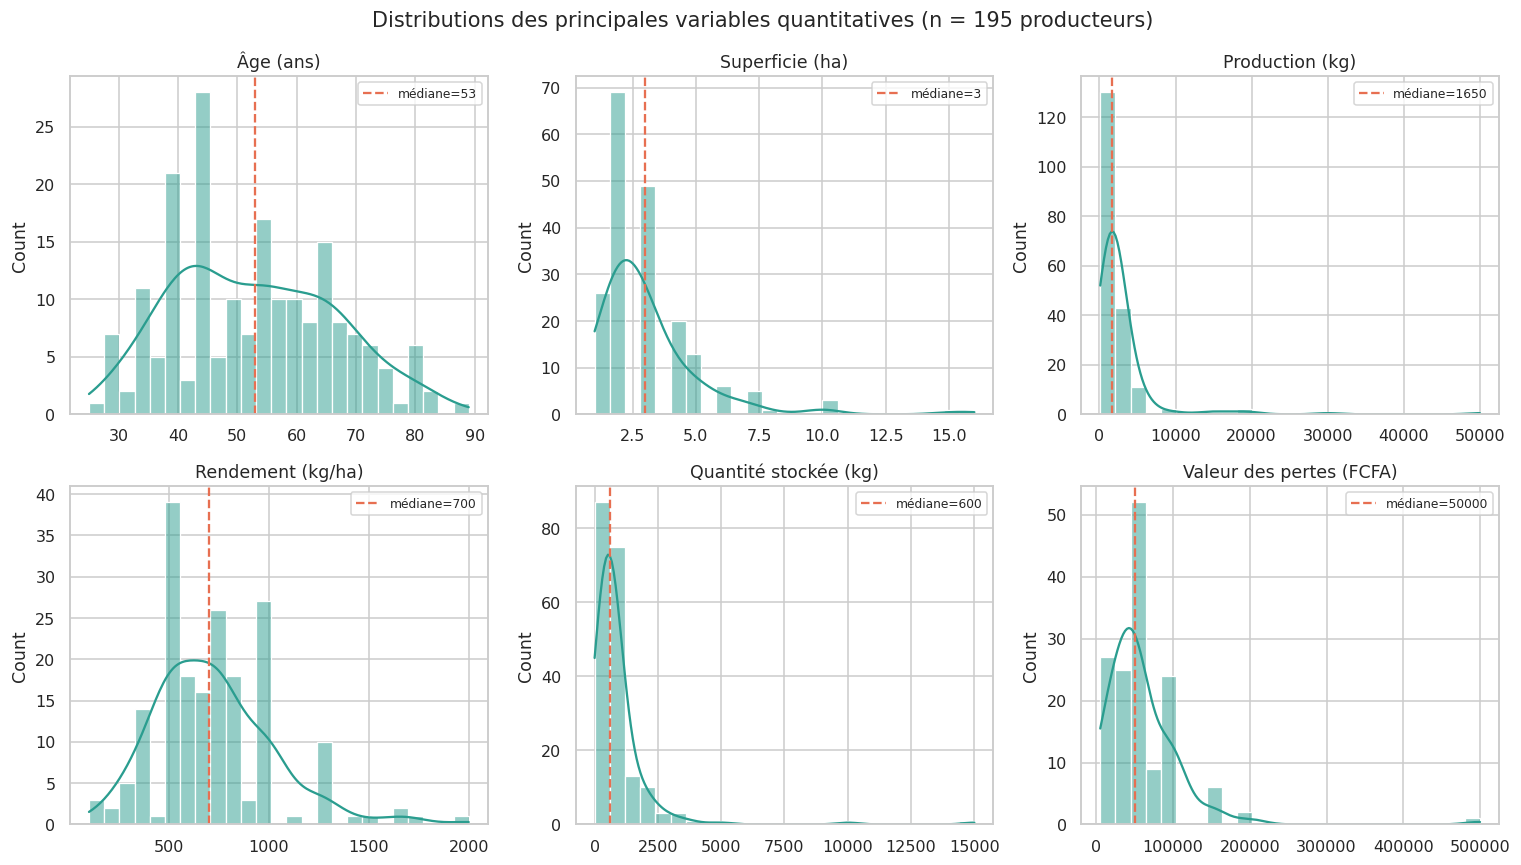

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, v, lab in zip(axes.ravel(),
                      ["age", "superficie_ha", "production_kg", "rendement_kg_ha", "qte_stockee_kg", "valeur_pertes_fcfa"],
                      ["Âge (ans)", "Superficie (ha)", "Production (kg)", "Rendement (kg/ha)", "Quantité stockée (kg)", "Valeur des pertes (FCFA)"]):
    sns.histplot(enq[v].dropna(), kde=True, ax=ax, color="#2a9d8f", bins=25)
    ax.axvline(enq[v].median(), color="#e76f51", ls="--", label=f"médiane={enq[v].median():.0f}")
    ax.set_title(lab); ax.set_xlabel(""); ax.legend(fontsize=8)
fig.suptitle("Distributions des principales variables quantitatives (n = 195 producteurs)")
savefig("04_distributions_numeriques")

Les distributions de production, superficie, stock et valeur des pertes sont **asymétriques à droite** (quelques gros producteurs) : les tests non paramétriques (Mann-Whitney, Kruskal-Wallis, Spearman) et les médianes seront privilégiés.

### 4.2 Variables catégorielles de l'enquête

In [15]:
def freq_table(col, title=None):
    t = enq[col].value_counts(dropna=False)
    out = pd.DataFrame({"effectif": t, "%": (100 * t / len(enq)).round(1)})
    out.index.name = title or col
    return out

cat_vars = ["sexe", "classe_age", "instruction_grp", "formation", "commune", "classe_superficie", "battage",
            "perte_sechage", "perte_battage", "lieu_stockage", "mode_stockage", "duree_stockage", "nature_traitement",
            "freq_traitement", "pertes_stockage", "couverture_alim", "financement", "consequences_sociales"]
for c in cat_vars:
    display(freq_table(c))

,effectif,%
sexe,,
Masculin,191,97.9
Féminin,4,2.1


,effectif,%
classe_age,,
40-54,81,41.5
65+,44,22.6
55-64,42,21.5
<40,28,14.4


,effectif,%
instruction_grp,,
Coranique,164,84.1
École formelle,24,12.3
Aucun,7,3.6


,effectif,%
formation,,
0,182,93.3
1,13,6.7


,effectif,%
commune,,
Nioro Alassane Tall,87,44.6
Keur Samba Guèye,76,39.0
Keur Saloum Diané,32,16.4


...

,effectif,%
freq_traitement,,
Une fois,156,80.0
Aucun,23,11.8
Deux fois,16,8.2


,effectif,%
pertes_stockage,,
1,145,74.4
0,50,25.6


,effectif,%
couverture_alim,,
0,163,83.6
1,32,16.4


,effectif,%
financement,,
Fonds propres,115,59.0
Emprunt / banque,59,30.3
Mixte (fonds propres + emprunt),16,8.2
Non concerné,5,2.6


,effectif,%
consequences_sociales,,
1,122,62.6
0,73,37.4


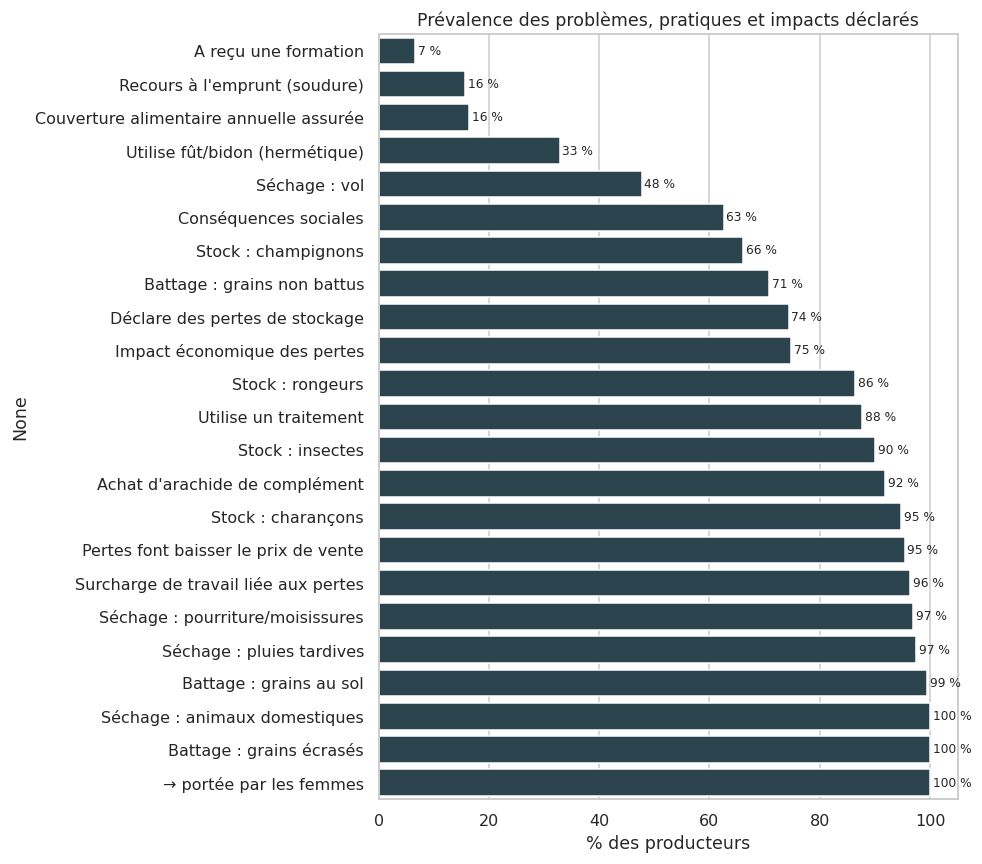

In [16]:
# Vue synthétique des indicateurs binaires (prévalences)
bin_vars = {
    "Séchage : pluies tardives": "sech_pluies", "Séchage : animaux domestiques": "sech_animaux", "Séchage : vol": "sech_vol",
    "Séchage : pourriture/moisissures": "sech_moisissure",
    "Battage : grains non battus": "batt_non_battus", "Battage : grains écrasés": "batt_ecrases", "Battage : grains au sol": "batt_sol",
    "Stock : insectes": "ennemi_insectes", "Stock : charançons": "ennemi_charancons", "Stock : rongeurs": "ennemi_rongeurs",
    "Stock : champignons": "ennemi_champignons",
    "Utilise un traitement": "traitement", "Utilise fût/bidon (hermétique)": "stock_hermetique",
    "Déclare des pertes de stockage": "pertes_stockage", "Impact économique des pertes": "impact_pertes",
    "Conséquences sociales": "consequences_sociales", "Achat d'arachide de complément": "achat_supplementaire",
    "Pertes font baisser le prix de vente": "baisse_prix", "Surcharge de travail liée aux pertes": "surcharge_travail",
    "→ portée par les femmes": "travail_femmes", "Couverture alimentaire annuelle assurée": "couverture_alim",
    "Recours à l'emprunt (soudure)": "soudure_emprunt", "A reçu une formation": "formation",
}
prev = pd.Series({k: 100 * enq[v].mean() for k, v in bin_vars.items()}).sort_values()
plt.figure(figsize=(9, 8))
sns.barplot(x=prev.values, y=prev.index, color="#264653")
for i, v in enumerate(prev.values):
    plt.text(v + 0.5, i, f"{v:.0f} %", va="center", fontsize=8)
plt.xlabel("% des producteurs"); plt.title("Prévalence des problèmes, pratiques et impacts déclarés")
savefig("04_prevalences")

**Lecture** : l'échantillon est très homogène sur les pratiques (séchage au sol au champ à 100 %, battage manuel 89 %, sacs plastiques 94 %, traitement chimique 85 %, cases cimentées 95 %). Les problèmes de séchage sont quasi universels (pluies tardives 97 %, animaux 100 %, moisissures 96 %) et **90 % jugent les pertes au séchage importantes**, alors que **92 % jugent les pertes au battage négligeables** : le séchage est l'étape pré-stockage la plus critique. Au stockage, insectes (97 %) et champignons (66 %) dominent. Trois producteurs sur quatre déclarent des pertes de stockage et 92 % doivent racheter de l'arachide en cours d'année ; la charge de travail supplémentaire (tri, surveillance) repose sur les **femmes dans 97 % des cas**.

### 4.3 Pertes mesurées (fiche de relevé)

In [17]:
desc_p = poids.groupby("nature").agg(
    n_lots=("taux_perte", "size"), poids_initial_total_kg=("poids_initial", "sum"), poids_initial_median=("poids_initial", "median"),
    perte_totale_kg=("perte_kg", "sum"), taux_moyen=("taux_perte", "mean"), taux_median=("taux_perte", "median"),
    taux_ecart_type=("taux_perte", "std"), taux_Q3=("taux_perte", lambda x: x.quantile(.75)), taux_max=("taux_perte", "max"),
    pct_lots_avec_perte=("perte_positive", lambda x: 100 * x.mean()))
desc_p["taux_pondere_%"] = 100 * desc_p["perte_totale_kg"] / desc_p["poids_initial_total_kg"]
desc_p.round(2).T

nature,Décortiqué,Gousses
n_lots,96.00,96.00
poids_initial_total_kg,47570.00,65650.00
poids_initial_median,250.00,400.00
perte_totale_kg,2555.00,1470.00
taux_moyen,7.99,3.83
taux_median,0.00,0.00
taux_ecart_type,13.31,7.90
taux_Q3,14.88,0.00
taux_max,50.00,33.33
pct_lots_avec_perte,34.38,23.96


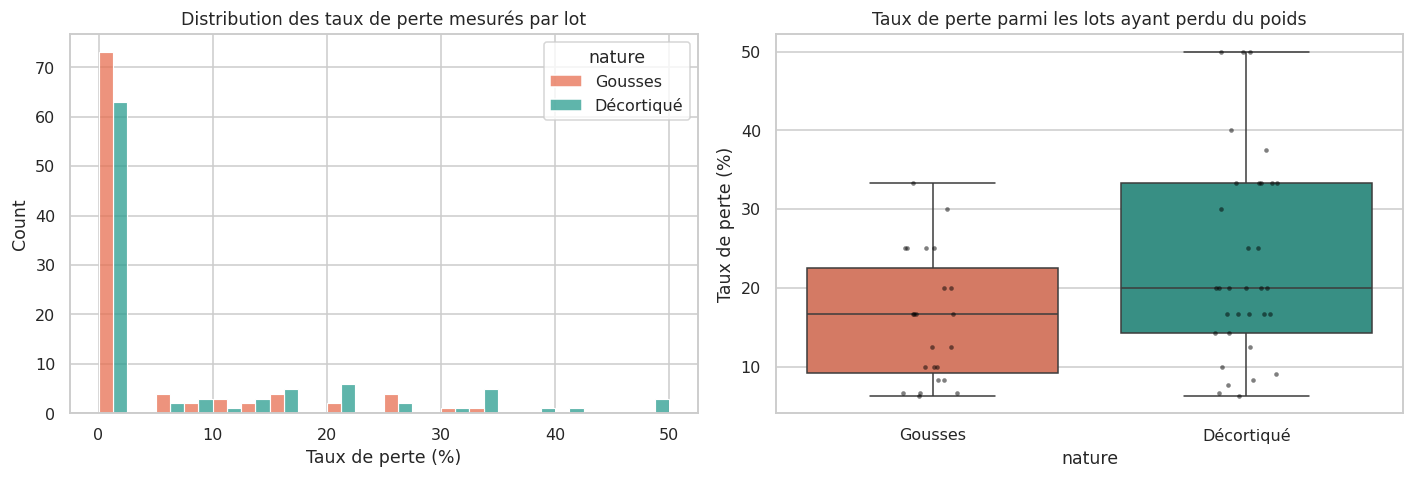

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=poids, x="taux_perte", hue="nature", bins=20, ax=axes[0], multiple="dodge", palette=["#e76f51", "#2a9d8f"])
axes[0].set_title("Distribution des taux de perte mesurés par lot"); axes[0].set_xlabel("Taux de perte (%)")
sub = poids[poids.perte_positive == 1]
sns.boxplot(data=sub, x="nature", y="taux_perte", ax=axes[1], palette=["#e76f51", "#2a9d8f"])
sns.stripplot(data=sub, x="nature", y="taux_perte", ax=axes[1], color="black", alpha=.5, size=3)
axes[1].set_title("Taux de perte parmi les lots ayant perdu du poids"); axes[1].set_ylabel("Taux de perte (%)")
savefig("04_taux_perte_mesure")

**Lecture** :
- **Gousses** : taux moyen **3,8 %** (pondéré par le poids : 2,2 %), 24 % des lots ont perdu du poids ; parmi eux la perte médiane est ≈ 15 %.
- **Décortiqué** : taux moyen **8,0 %** (pondéré : 5,4 %), 34 % des lots affectés, pertes jusqu'à 50 %.
- Les distributions sont en « masse à zéro + queue » : beaucoup de lots sans perte détectée (précision de la pesée de 25–50 kg, soit une résolution grossière pour des lots de 100–300 kg), et une minorité de lots fortement affectés → l'analyse portera à la fois sur la **probabilité de perte** et sur **l'intensité**.

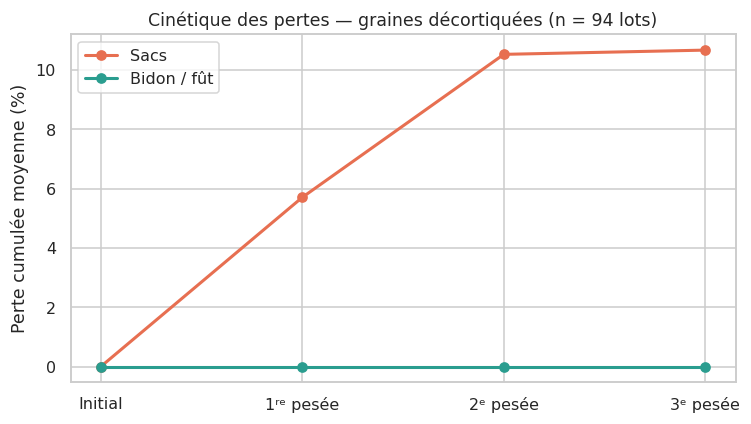

,Sacs,Bidon / fût
Initial,0.00,0.0
1ʳᵉ pesée,5.70,0.0
2ᵉ pesée,10.52,0.0
3ᵉ pesée,10.67,0.0


In [19]:
# Cinétique des pertes sur les 3 pesées (décortiqué)
d3 = poids[(poids.nature == "Décortiqué") & (poids.nb_pesees == 3)].copy()
for i, c in enumerate(["pesee_1", "pesee_2", "pesee_3"], 1):
    d3[f"t{i}"] = 100 * (d3.poids_initial - d3[c]) / d3.poids_initial
kin = d3.groupby("stockage_hermetique")[["t1", "t2", "t3"]].mean().T
kin.columns = ["Sacs", "Bidon / fût"]
kin.loc["t0"] = 0
kin = kin.sort_index()
kin.index = ["Initial", "1ʳᵉ pesée", "2ᵉ pesée", "3ᵉ pesée"]
plt.figure(figsize=(7, 4))
for c, col in zip(kin.columns, ["#e76f51", "#2a9d8f"]):
    plt.plot(kin.index, kin[c], marker="o", label=c, color=col, lw=2)
plt.ylabel("Perte cumulée moyenne (%)"); plt.title("Cinétique des pertes — graines décortiquées (n = 94 lots)"); plt.legend()
savefig("04_cinetique_decortique")
kin.round(2)

La perte du décortiqué s'installe surtout entre la 1ʳᵉ et la 2ᵉ pesée (4,2 % → 7,8 %) puis plafonne ; **aucune perte n'a été mesurée dans les contenants hermétiques** sur l'ensemble du suivi.

---
## ÉTAPE 5 — Analyse exploratoire (EDA)

### 5.1 Profil démographique

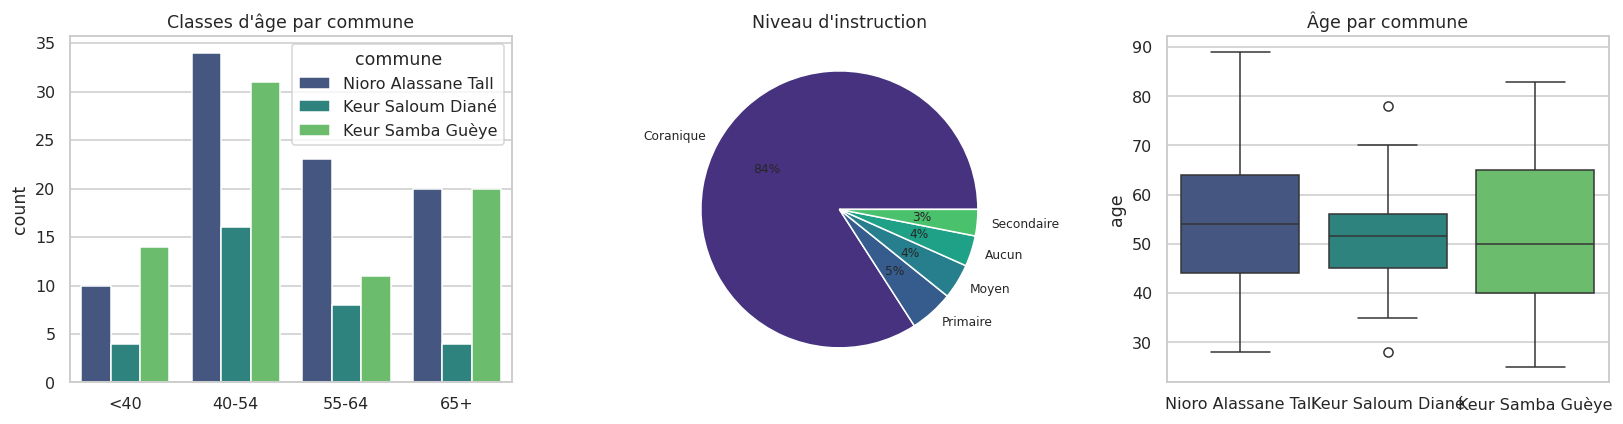

sexe                 Féminin  Masculin  All
commune                                    
Keur Saloum Diané          0        32   32
Keur Samba Guèye           2        74   76
Nioro Alassane Tall        2        85   87
All                        4       191  195

Âge par commune :
                     count  mean   std   min   25%   50%   75%   max
commune                                                             
Keur Saloum Diané     32.0  51.1  10.8  28.0  45.0  51.5  56.0  78.0
Keur Samba Guèye      76.0  52.2  15.4  25.0  40.0  50.0  65.0  83.0
Nioro Alassane Tall   87.0  53.9  13.0  28.0  44.0  54.0  64.0  89.0
Kruskal-Wallis âge ~ commune : KruskalResult(statistic=np.float64(1.2256615412237946), pvalue=np.float64(0.5418149423561316))


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=enq, x="classe_age", hue="commune", ax=axes[0], palette="viridis"); axes[0].set_title("Classes d'âge par commune"); axes[0].set_xlabel("")
enq["instruction"].value_counts().plot.pie(ax=axes[1], autopct="%1.0f%%", colors=sns.color_palette("viridis", 6), textprops={"fontsize": 8}); axes[1].set_ylabel(""); axes[1].set_title("Niveau d'instruction")
sns.boxplot(data=enq, x="commune", y="age", ax=axes[2], palette="viridis"); axes[2].set_title("Âge par commune"); axes[2].set_xlabel("")
savefig("05_demographie")
print(pd.crosstab(enq.commune, enq.sexe, margins=True))
print("\nÂge par commune :"); print(enq.groupby("commune")["age"].describe().round(1))
print("Kruskal-Wallis âge ~ commune :", stats.kruskal(*[g.age for _, g in enq.groupby("commune")]))

- **Quasi-exclusivement masculin** (98 %) : les 4 femmes enquêtées sont plus jeunes (42 ans en moyenne) et exploitent des surfaces plus petites (1,5 ha). L'enquête ne capte donc pas le point de vue des femmes, pourtant en première ligne de la gestion des pertes.
- Instruction : 84 % coranique, 12 % école formelle, 4 % aucun. Formation technique reçue : **7 %** seulement, concentrée à Nioro Alassane Tall.
- Les communes ne diffèrent pas significativement par l'âge (p > 0,05).

### 5.2 Profil agricole par commune et village

In [21]:
agri = enq.groupby("commune").agg(n=("id", "size"), superficie_med=("superficie_ha", "median"), production_med=("production_kg", "median"),
                                   rendement_med=("rendement_kg_ha", "median"), stock_med=("qte_stockee_kg", "median"),
                                   pct_vente=("pct_vente", "mean"), pct_autoconso=("pct_autoconso", "mean"),
                                   hermetique_pct=("stock_hermetique", lambda x: 100 * x.mean()), traitement_pct=("traitement", lambda x: 100 * x.mean()),
                                   pertes_declarees_pct=("pertes_stockage", lambda x: 100 * x.mean()), valeur_pertes_med=("valeur_pertes_fcfa", "median"),
                                   couverture_alim_pct=("couverture_alim", lambda x: 100 * x.mean()))
agri.round(1).T

commune,Keur Saloum Diané,Keur Samba Guèye,Nioro Alassane Tall
n,32.0,76.0,87.0
superficie_med,2.0,3.0,2.0
production_med,1500.0,1500.0,2000.0
rendement_med,666.7,612.5,750.0
stock_med,500.0,600.0,600.0
pct_vente,60.3,65.9,60.8
pct_autoconso,25.0,14.7,23.3
hermetique_pct,6.2,40.8,35.6
traitement_pct,96.9,76.3,94.3
pertes_declarees_pct,87.5,55.3,86.2


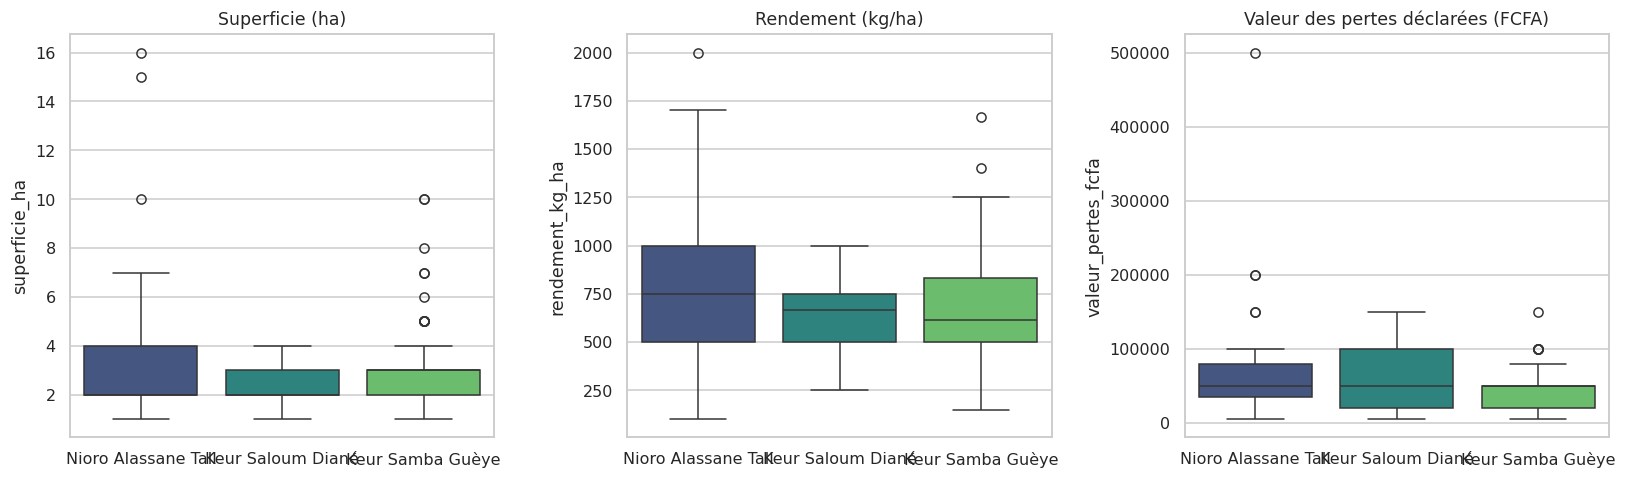

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=enq, x="commune", y="superficie_ha", ax=axes[0], palette="viridis"); axes[0].set_title("Superficie (ha)"); axes[0].set_xlabel("")
sns.boxplot(data=enq, x="commune", y="rendement_kg_ha", ax=axes[1], palette="viridis"); axes[1].set_title("Rendement (kg/ha)"); axes[1].set_xlabel("")
sns.boxplot(data=enq, x="commune", y="valeur_pertes_fcfa", ax=axes[2], palette="viridis"); axes[2].set_title("Valeur des pertes déclarées (FCFA)"); axes[2].set_xlabel("")
savefig("05_agri_par_commune")

In [23]:
vil = enq.groupby(["commune", "village"]).agg(n=("id", "size"), rendement=("rendement_kg_ha", "median"), production=("production_kg", "median"),
                                              pertes_decl=("pertes_stockage", "mean"), hermetique=("stock_hermetique", "mean"),
                                              valeur_pertes=("valeur_pertes_fcfa", "median")).round(2)
mes = poids.groupby(["village", "nature"])["taux_perte"].mean().unstack().round(1).rename(columns={"Gousses": "perte_mesuree_gousses_%", "Décortiqué": "perte_mesuree_decort_%"})
vil = vil.join(mes, on="village")
vil

n  rendement  production  pertes_decl  hermetique  valeur_pertes  perte_mesuree_decort_%  perte_mesuree_gousses_%
commune             village                                                                                                                                   
Keur Saloum Diané   Keur Babou Ndity         9     750.00      1500.0         0.89        0.11        50000.0                    25.0                      5.8
                    Keur Bacar Santie        7     750.00      1000.0         0.86        0.00        50000.0                    14.2                      8.3
                    Ndayene Keur Momath      7     666.67      2000.0         1.00        0.14        20000.0                     0.0                      0.0
                    Thiarene Babou           9     600.00      1500.0         0.78        0.00       100000.0                     7.3                      2.0
Keur Samba Guèye    Keur Ayib Ka            27     700.00      2500.0         0.56        0.48        20000.0                     3.3                      2.1
                    Keur Momath Souna        9     500.00      1498.0         0.78        0.00        50000.0                     4.0                      8.3
                    Keur Samba Nosso        17     666.67      2000.0         0.29        0.88        62500.0                     4.2                      1.5
                    Medina Djikoy           11     500.00      1500.0         0.64        0.18        50000.0                     8.3                      6.2
                    Passy Ndendrling        12     650.00      1650.0         0.67        0.08        50000.0                    14.6                      4.4
Nioro Alassane Tall Keur Malick Fady         7     666.67      2000.0         1.00        0.14        30000.0                     3.1                      0.0
                    Ndiayene Moussa Ndiaye  10     791.67      2000.0         0.80        0.30        50000.0                    13.3                      8.5
                    Pakala                  25     700.00      1500.0         0.72        0.40        50000.0                     4.7                      2.4
                    Simong Bambara           6     700.00      1650.0         1.00        0.33        60000.0                    16.7                     11.1
                    Simong Diene             9    1000.00      2000.0         0.78        0.56        52500.0                     0.0                      0.0
                    Touba Mouride           30     750.00      2000.0         0.97        0.33        50000.0                    11.7                      4.1

**Tendances / profils** :
- Keur Saloum Diané : plus petites exploitations (médiane 2 ha, production 1 200 kg), stock quasi exclusivement en sacs (9 % hermétique), pertes déclarées par 88 % — *profil vulnérable*.
- Keur Samba Guèye : exploitations plus grandes, **41 % utilisent un contenant hermétique**, seuls 55 % déclarent des pertes ; les pertes mesurées y sont aussi les plus faibles — *profil relativement performant*.
- Nioro Alassane Tall : production élevée mais 86 % de pertes déclarées, valeur des pertes la plus élevée (médiane 50 000 FCFA, moyenne 68 000) — *profil à fort enjeu économique*.
- Villages à surveiller : Keur Babou Ndity, Simong Bambara, Keur Momath Souna, Touba Mouride (pertes mesurées sur décortiqué > 10 %).

### 5.3 Anomalies et comportements notables

In [24]:
print("Producteurs stockant > 50 % de leur production :", (enq.part_stockee > .5).sum())
print("Producteurs sans traitement ET en sacs uniquement :", ((enq.traitement == 0) & (enq.mode_stockage == "Sacs uniquement")).sum())
print("Producteurs déclarant des pertes mais sans valeur chiffrée :", ((enq.pertes_stockage == 1) & enq.valeur_pertes_fcfa.isna()).sum())
print("Producteurs déclarant NE PAS avoir de pertes mais un impact économique :", ((enq.pertes_stockage == 0) & (enq.impact_pertes == 1)).sum())
print("Lots test (ail / bidons sans traitement) :", enq.lot_test.sum())
print("\nSolutions spontanément proposées (Q4.1, n =", enq.sol_repondu.sum(), "répondants) :")
print(pd.Series({"Magasin de stockage": enq.sol_magasin.sum(), "Fûts / bidons": enq.sol_fut_bidon.sum(), "Produits de traitement efficaces": enq.sol_produits.sum()}))

Producteurs stockant > 50 % de leur production : 16
Producteurs sans traitement ET en sacs uniquement : 6
Producteurs déclarant des pertes mais sans valeur chiffrée : 7
Producteurs déclarant NE PAS avoir de pertes mais un impact économique : 8
Lots test (ail / bidons sans traitement) : 7

Solutions spontanément proposées (Q4.1, n = 85 répondants) :
Magasin de stockage                 54
Fûts / bidons                       27
Produits de traitement efficaces    19
dtype: int64


---
## ÉTAPE 6 — Analyse bivariée

### 6.1 Corrélations entre variables quantitatives

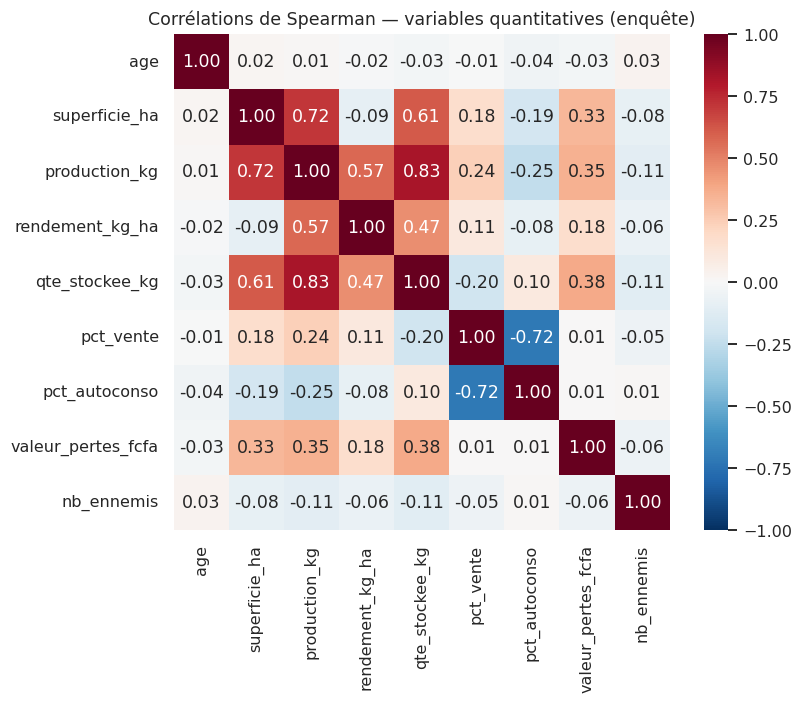

In [25]:
corr_vars = ["age", "superficie_ha", "production_kg", "rendement_kg_ha", "qte_stockee_kg", "pct_vente", "pct_autoconso", "valeur_pertes_fcfa", "nb_ennemis"]
corr = enq[corr_vars].corr(method="spearman")
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
plt.title("Corrélations de Spearman — variables quantitatives (enquête)")
savefig("06_heatmap_correlations")

- Superficie, production et quantité stockée sont fortement corrélées (ρ = 0,65–0,85) : la taille d'exploitation est le facteur structurant.
- **Valeur des pertes ↔ production (ρ = 0,35) et ↔ stock (ρ = 0,38)** : les pertes monétaires croissent avec le volume stocké (H5 confirmée, cf. tests).
- Rendement ↔ superficie : ρ = −0,09, non significatif : pas d'effet d'échelle sur le rendement (H8 rejetée).
- Part vendue ↔ autoconsommation : ρ = −0,83 (mécanique) ; part vendue ↔ superficie : ρ = +0,33 : les grandes exploitations sont plus tournées vers le marché.

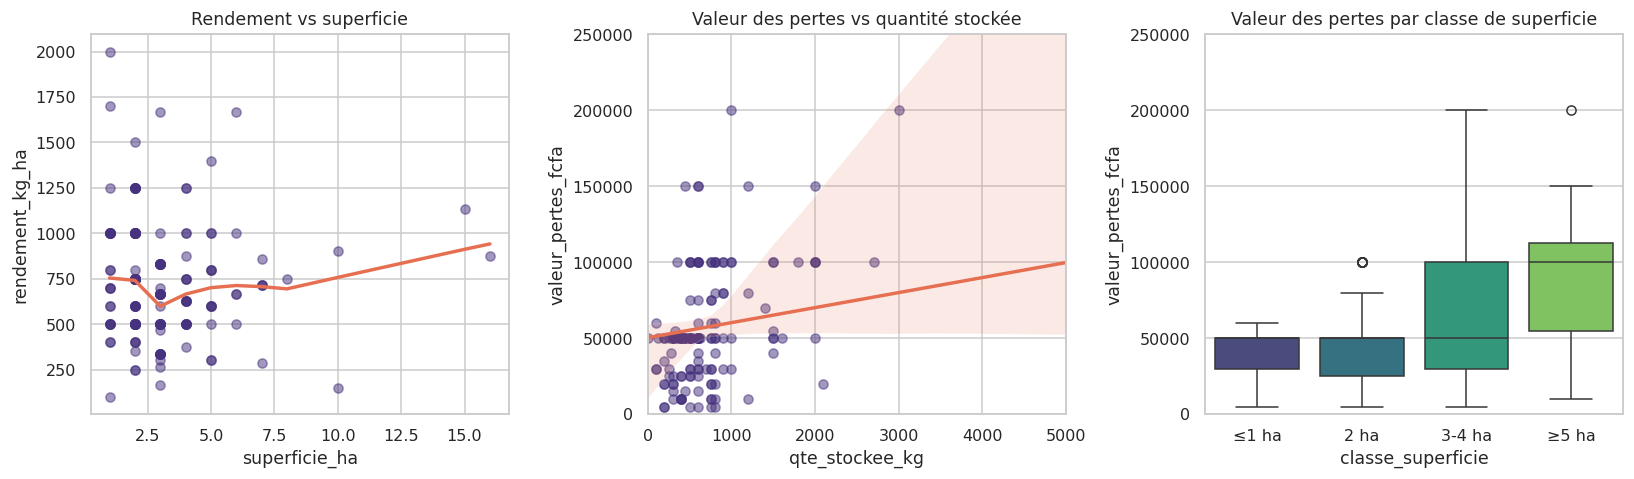

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.regplot(data=enq, x="superficie_ha", y="rendement_kg_ha", ax=axes[0], scatter_kws={"alpha": .5}, line_kws={"color": "#e76f51"}, lowess=True); axes[0].set_title("Rendement vs superficie")
sns.regplot(data=enq, x="qte_stockee_kg", y="valeur_pertes_fcfa", ax=axes[1], scatter_kws={"alpha": .5}, line_kws={"color": "#e76f51"}); axes[1].set_title("Valeur des pertes vs quantité stockée"); axes[1].set_xlim(0, 5000); axes[1].set_ylim(0, 250000)
sns.boxplot(data=enq, x="classe_superficie", y="valeur_pertes_fcfa", ax=axes[2], palette="viridis"); axes[2].set_title("Valeur des pertes par classe de superficie"); axes[2].set_ylim(0, 250000)
savefig("06_nuages")

### 6.2 Tableaux croisés — déclaration de pertes de stockage

In [27]:
def crosstab_pct(row, col="pertes_stockage", data=None):
    data = enq if data is None else data
    t = pd.crosstab(data[row], data[col])
    out = (100 * t.div(t.sum(axis=1), axis=0)).round(1)
    out.columns = [f"{col}={c} (%)" for c in out.columns]
    out["n"] = t.sum(axis=1)
    return out

for v in ["commune", "mode_stockage", "nature_traitement", "freq_traitement", "duree_stockage", "classe_superficie", "formation", "instruction_grp"]:
    display(crosstab_pct(v))

,pertes_stockage=0 (%),pertes_stockage=1 (%),n
commune,,,
Keur Saloum Diané,12.5,87.5,32
Keur Samba Guèye,44.7,55.3,76
Nioro Alassane Tall,13.8,86.2,87


,pertes_stockage=0 (%),pertes_stockage=1 (%),n
mode_stockage,,,
Hermétique uniquement,93.8,6.2,16
Sacs + hermétique,39.6,60.4,48
Sacs uniquement,12.2,87.8,131


,pertes_stockage=0 (%),pertes_stockage=1 (%),n
nature_traitement,,,
Aucun,62.5,37.5,24
Chimiques,18.1,81.9,166
Naturels,100.0,0.0,5


,pertes_stockage=0 (%),pertes_stockage=1 (%),n
freq_traitement,,,
Aucun,60.9,39.1,23
Deux fois,25.0,75.0,16
Une fois,20.5,79.5,156


,pertes_stockage=0 (%),pertes_stockage=1 (%),n
duree_stockage,,,
1 à 3 mois,0.0,100.0,2
3 à 6 mois,12.5,87.5,24
Plus de 6 mois,27.8,72.2,169


,pertes_stockage=0 (%),pertes_stockage=1 (%),n
classe_superficie,,,
≤1 ha,19.2,80.8,26
2 ha,24.6,75.4,69
3-4 ha,24.6,75.4,69
≥5 ha,33.3,66.7,30


,pertes_stockage=0 (%),pertes_stockage=1 (%),n
formation,,,
0,26.9,73.1,182
1,7.7,92.3,13


,pertes_stockage=0 (%),pertes_stockage=1 (%),n
instruction_grp,,,
Aucun,42.9,57.1,7
Coranique,25.6,74.4,164
École formelle,20.8,79.2,24


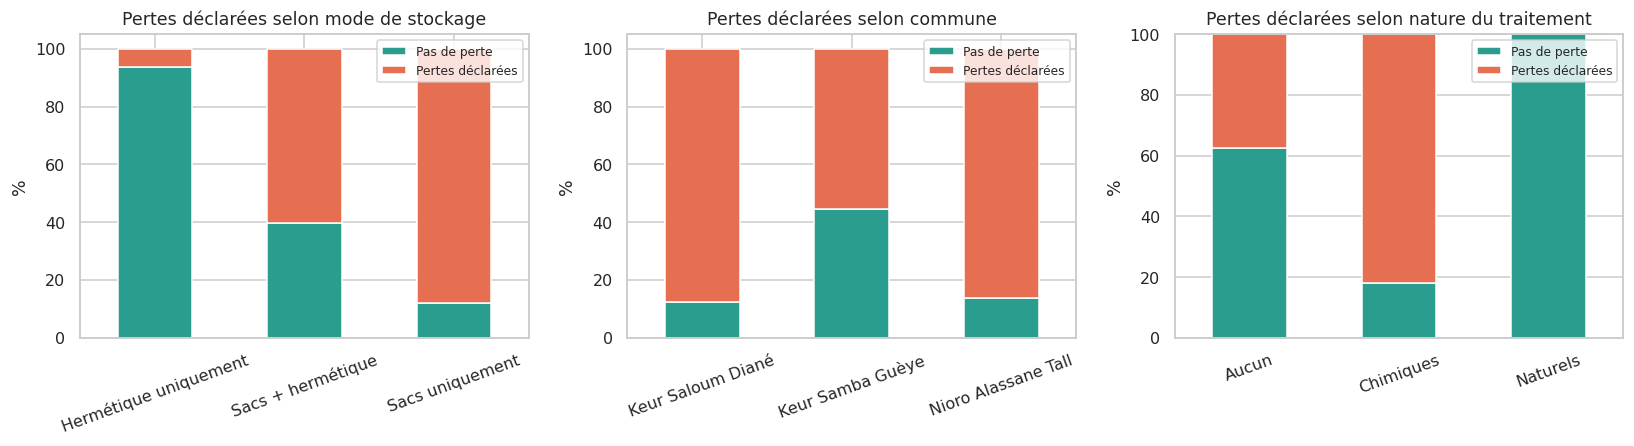

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, v, t in zip(axes, ["mode_stockage", "commune", "nature_traitement"], ["Mode de stockage", "Commune", "Nature du traitement"]):
    ct = pd.crosstab(enq[v], enq["pertes_stockage"], normalize="index") * 100
    ct.plot.bar(stacked=True, ax=ax, color=["#2a9d8f", "#e76f51"], rot=20); ax.set_title(f"Pertes déclarées selon {t.lower()}"); ax.set_ylabel("%"); ax.set_xlabel("")
    ax.legend(["Pas de perte", "Pertes déclarées"], fontsize=8)
savefig("06_pertes_declarees_croisees")

**Résultats marquants** : les pertes déclarées passent de **88 % (sacs uniquement) à 60 % (sacs + contenant hermétique) et 6 % (hermétique uniquement)**. Le traitement chimique n'est pas protecteur en apparence (82 % de pertes chez les traités vs 38 % chez les non-traités) : effet de **confusion** — les non-traités sont précisément ceux qui stockent en bidons/fûts. Cette confusion sera levée par l'analyse multivariée (étape 8).

### 6.3 Pertes mesurées selon les pratiques de stockage

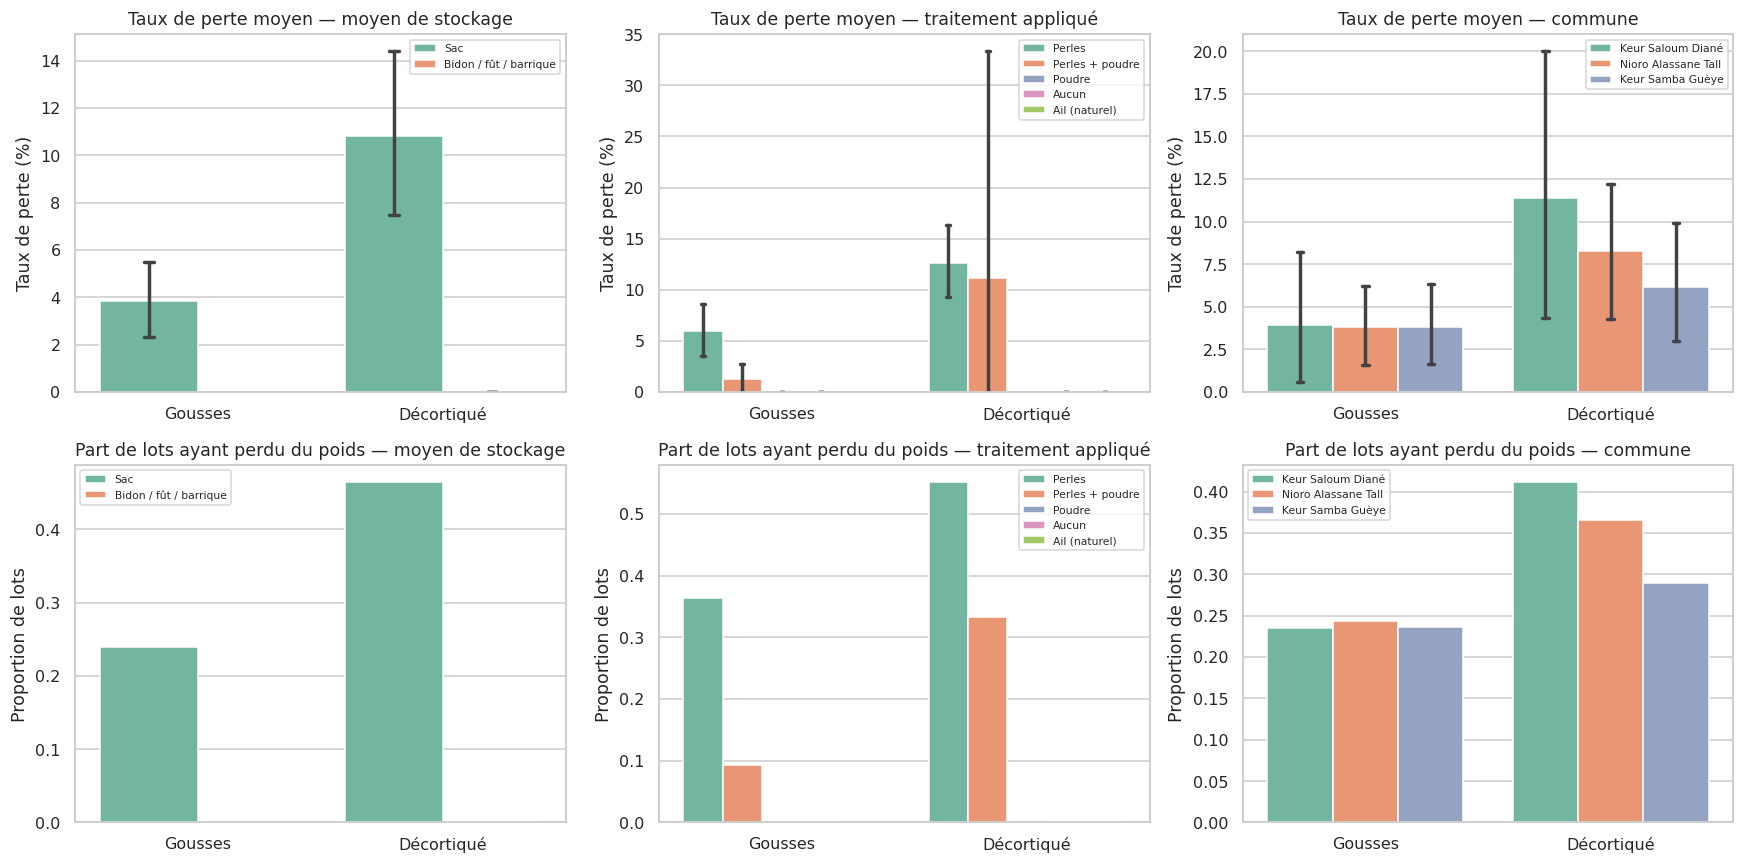

n  taux_moyen  pct_lots_touches
nature     moyen_stockage traitement_cat                                   
Décortiqué Barrique       Aucun             1         0.0               0.0
           Bidon          Ail (naturel)     3         0.0               0.0
                          Aucun            15         0.0               0.0
           Fût            Ail (naturel)     1         0.0               0.0
                          Aucun             3         0.0               0.0
                          Perles            2         0.0               0.0
           Sac            Ail (naturel)     1         0.0               0.0
                          Aucun            11         0.0               0.0
                          Perles           56        13.1              57.1
                          Perles + poudre   3        11.1              33.3
Gousses    Sac            Aucun             3         0.0               0.0
                          Perles           55         5.9              36.4
                          Perles + poudre  32         1.3               9.4
                          Poudre            6         0.0               0.0

In [29]:
# Les distributions étant concentrées en 0, on compare les taux moyens (avec IC 95 % bootstrap) et la part de lots touchés
poids["contenant"] = np.where(poids.stockage_hermetique == 1, "Bidon / fût / barrique", "Sac")
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for j, (v, t) in enumerate([("contenant", "Moyen de stockage"), ("traitement_cat", "Traitement appliqué"), ("commune", "Commune")]):
    sns.barplot(data=poids, x="nature", y="taux_perte", hue=v, ax=axes[0, j], palette="Set2", errorbar=("ci", 95), capsize=.08)
    axes[0, j].set_title(f"Taux de perte moyen — {t.lower()}"); axes[0, j].set_xlabel(""); axes[0, j].set_ylabel("Taux de perte (%)"); axes[0, j].legend(fontsize=7)
    sns.barplot(data=poids, x="nature", y="perte_positive", hue=v, ax=axes[1, j], palette="Set2", errorbar=None)
    axes[1, j].set_title(f"Part de lots ayant perdu du poids — {t.lower()}"); axes[1, j].set_xlabel(""); axes[1, j].set_ylabel("Proportion de lots"); axes[1, j].legend(fontsize=7)
savefig("06_pertes_mesurees_pratiques")

tab = poids.groupby(["nature", "moyen_stockage", "traitement_cat"]).agg(n=("taux_perte", "size"), taux_moyen=("taux_perte", "mean"), pct_lots_touches=("perte_positive", lambda x: 100 * x.mean())).round(1)
tab

- **Décortiqué en sacs : 10,8 % de perte moyenne ; en bidon/fût/barrique : 0 %** (25 lots, aucune perte détectée).
- Gousses : toutes en sacs ; les lots traités **perles + poudre** perdent 1,3 % contre 5,9 % pour les perles seules.
- Les dégâts signalés sur décortiqué sont trouaison (18 %) et moisissures (16 %) ; sur gousses, trouaison (19 %) — signature d'attaques d'insectes (bruches) en sacs.

In [30]:
# Lien pertes mesurées ↔ déclarations (échantillon apparié)
merged = poids.drop(columns=["cle_village_enq"]).merge(enq, left_on="id_enq", right_on="id", suffixes=("", "_enq"))
print("Lots appariés :", len(merged))
display(merged.groupby(["nature", "pertes_stockage"])["taux_perte"].agg(["mean", "median", "count"]).round(2))
display(merged.groupby(["nature", "mode_stockage"])["taux_perte"].agg(["mean", "count"]).round(2))

Lots appariés : 146


mean  median  count
nature     pertes_stockage                     
Décortiqué 0                3.52     0.0     16
           1                9.20     0.0     57
Gousses    0                1.98     0.0     16
           1                4.16     0.0     57

mean  count
nature     mode_stockage                     
Décortiqué Hermétique uniquement  0.00      5
           Sacs + hermétique      7.91     24
           Sacs uniquement        8.88     44
Gousses    Hermétique uniquement  0.00      5
           Sacs + hermétique      4.36     24
           Sacs uniquement        3.73     44

Cohérence entre les deux sources : les producteurs qui **déclarent** des pertes ont des pertes **mesurées** 2 à 2,6 fois plus élevées (décortiqué : 9,2 % vs 3,5 %). Les déclarations sont donc un indicateur fiable, mais qui surestime la prévalence (75 % déclarent vs 24–34 % de lots avec perte mesurée sur la période de suivi).

---
## ÉTAPE 7 — Tests statistiques

Choix des tests : variables cibles non normales (Shapiro p < 0,001) → tests non paramétriques ; effectifs de cellules < 5 → test exact de Fisher à la place du χ².

In [31]:
print("Normalité (Shapiro-Wilk) :")
for v in ["taux_perte", "valeur_pertes_fcfa", "rendement_kg_ha", "production_kg"]:
    s = (poids if v == "taux_perte" else enq)[v].dropna()
    print(f"  {v:22s} W={stats.shapiro(s)[0]:.3f}  p={stats.shapiro(s)[1]:.2e}")

results = []
def add(test, h0, h1, stat, p, n, interpretation):
    results.append({"Test": test, "H0": h0, "H1": h1, "Statistique": round(stat, 3), "p-value": p, "n": n,
                    "Décision (α=5%)": "Rejet H0 — significatif" if p < .05 else "Non rejet H0 — non significatif", "Interprétation métier": interpretation})

g = poids[poids.nature == "Gousses"]; d = poids[poids.nature == "Décortiqué"]

# H1 — Gousses vs décortiqué (Wilcoxon apparié sur les mêmes producteurs)
pair = poids.pivot_table(index=["cle_nom", "cle_village"], columns="nature", values="taux_perte", aggfunc="first").dropna()
w = stats.wilcoxon(pair["Décortiqué"], pair["Gousses"])
add("Wilcoxon apparié (H1)", "Taux de perte gousses = décortiqué chez un même producteur", "Décortiqué ≠ gousses", w.statistic, w.pvalue, len(pair),
    "Le décortiqué perd significativement plus (8,0 % vs 3,8 %) : la coque protège ; décortiquer avant stockage expose davantage aux insectes et moisissures.")

# H2 — Stockage hermétique vs sac (décortiqué, seul produit stocké en contenants)
mw = stats.mannwhitneyu(d[d.stockage_hermetique == 1].taux_perte, d[d.stockage_hermetique == 0].taux_perte)
add("Mann-Whitney (H2)", "Perte décortiqué identique en sac et en contenant hermétique", "Différence", mw.statistic, mw.pvalue,
    len(d), "0 % de perte en bidon/fût contre 10,8 % en sac : le contenant hermétique est le levier le plus efficace mesuré.")
ft = stats.fisher_exact(pd.crosstab(d.stockage_hermetique, d.perte_positive))
add("Fisher exact (H2 bis)", "Probabilité de perte indépendante du type de contenant", "Dépendance", ft[0], ft[1], len(d),
    "Aucun des 25 lots hermétiques n'a perdu de poids vs 33/71 lots en sac (46 %).")

# H3 — Traitement chimique (décortiqué en sacs uniquement, pour neutraliser l'effet contenant)
ds = d[d.moyen_stockage == "Sac"]
mw3 = stats.mannwhitneyu(ds[ds.traite_chimique == 1].taux_perte, ds[ds.traite_chimique == 0].taux_perte)
add("Mann-Whitney (H3, sacs seulement)", "Perte identique avec / sans traitement chimique (décortiqué en sac)", "Différence", mw3.statistic, mw3.pvalue, len(ds),
    "Résultat contre-intuitif : 13 % de perte sur les lots traités aux perles vs 0 % sur 12 lots non traités. Le traitement est appliqué de façon curative sur des stocks déjà infestés ou de plus grande taille ; un biais de sélection est probable. Le traitement chimique seul n'est pas une garantie.")
kw3 = stats.kruskal(*[x.taux_perte for _, x in g.groupby("traitement_cat")])
add("Kruskal-Wallis (H3 gousses)", "Perte gousses identique quel que soit le traitement", "Au moins un traitement diffère", kw3.statistic, kw3.pvalue, len(g),
    "Perles + poudre (1,3 %) < perles seules (5,9 %) : la combinaison fumigant + insecticide de contact est plus efficace (Mann-Whitney perles vs perles+poudre p = 0,007).")

# H4 — Commune / village
for nat, sub in [("gousses", g), ("décortiqué", d)]:
    kw = stats.kruskal(*[x.taux_perte for _, x in sub.groupby("commune")])
    add(f"Kruskal-Wallis (H4, {nat})", f"Perte {nat} identique entre communes", "Au moins une commune diffère", kw.statistic, kw.pvalue, len(sub),
        "Pas de différence significative entre communes : les pertes dépendent des pratiques individuelles plus que de la localisation.")
chi = stats.chi2_contingency(pd.crosstab(enq.commune, enq.pertes_stockage))
add("χ² (H4, déclarations)", "Déclaration de pertes indépendante de la commune", "Dépendance", chi[0], chi[1], len(enq),
    "Keur Samba Guèye déclare nettement moins de pertes (55 % vs 86–88 %) — commune où l'usage de fûts/bidons est le plus répandu (41 %).")

# H5 — Valeur des pertes ~ production / stock
for v, lab in [("production_kg", "production"), ("qte_stockee_kg", "quantité stockée"), ("superficie_ha", "superficie")]:
    sp = stats.spearmanr(enq.valeur_pertes_fcfa, enq[v], nan_policy="omit")
    add(f"Spearman (H5, {lab})", f"Valeur des pertes indépendante de la {lab}", "Corrélation monotone", sp.statistic, sp.pvalue, enq[["valeur_pertes_fcfa", v]].dropna().shape[0],
        f"ρ = {sp.statistic:.2f} : les pertes monétaires croissent avec la {lab} — les gros stockeurs subissent des pertes absolues plus lourdes.")

# H6 — Pertes de stockage et couverture alimentaire
ft6 = stats.fisher_exact(pd.crosstab(enq.pertes_stockage, enq.couverture_alim))
add("Fisher exact (H6)", "Couverture alimentaire indépendante des pertes de stockage", "Dépendance", ft6[0], ft6[1], len(enq),
    "24 % de couverture chez les sans-perte vs 14 % chez ceux qui perdent : tendance dans le sens attendu mais non significative (puissance limitée : seulement 32 ménages couverts).")
chi6 = stats.chi2_contingency(pd.crosstab(enq.classe_superficie, enq.couverture_alim))
add("χ² (H6 bis, superficie)", "Couverture alimentaire indépendante de la classe de superficie", "Dépendance", chi6[0], chi6[1], len(enq),
    "37 % des exploitations ≥ 5 ha couvrent l'année contre 8–13 % des autres : la taille d'exploitation est le premier déterminant de la sécurité alimentaire.")

# H7 — Formation / instruction
ft7 = stats.fisher_exact(pd.crosstab(enq.formation, enq.pertes_stockage))
add("Fisher exact (H7, formation)", "Déclaration de pertes indépendante de la formation reçue", "Dépendance", ft7[0], ft7[1], len(enq),
    "Non significatif (13 formés seulement) ; les formés déclarent même plus de pertes (92 %) — possible effet de sensibilisation (meilleure détection).")
chi7 = stats.chi2_contingency(pd.crosstab(enq.instruction_grp, enq.pertes_stockage))
add("χ² (H7, instruction)", "Déclaration de pertes indépendante du niveau d'instruction", "Dépendance", chi7[0], chi7[1], len(enq), "Aucun effet du niveau d'instruction.")

# H8 — Rendement ~ superficie / commune
sp8 = stats.spearmanr(enq.rendement_kg_ha, enq.superficie_ha, nan_policy="omit")
add("Spearman (H8)", "Rendement indépendant de la superficie", "Corrélation", sp8.statistic, sp8.pvalue, enq.rendement_kg_ha.notna().sum(),
    "Pas d'économie d'échelle : le rendement (≈ 700 kg/ha) est le même quelle que soit la taille — les gains de production passent par l'intensification, pas par l'extension.")
kw8 = stats.kruskal(*[x.rendement_kg_ha.dropna() for _, x in enq.groupby("commune")])
add("Kruskal-Wallis (H8 bis)", "Rendement identique entre communes", "Au moins une commune diffère", kw8.statistic, kw8.pvalue, enq.rendement_kg_ha.notna().sum(),
    "Nioro Alassane Tall légèrement au-dessus (médiane 750 vs 667 kg/ha), différence à la limite de la significativité (p ≈ 0,07).")

# Complément : déclarations vs mode de stockage / traitement
chi9 = stats.chi2_contingency(pd.crosstab(enq.mode_stockage, enq.pertes_stockage))
add("χ² (mode de stockage déclaré)", "Déclaration de pertes indépendante du mode de stockage", "Dépendance", chi9[0], chi9[1], len(enq),
    "88 % de pertes en sacs seuls, 60 % en mixte, 6 % en hermétique seul : confirme H2 sur les données déclaratives.")

tests = pd.DataFrame(results)
tests["p-value"] = tests["p-value"].map(lambda p: f"{p:.4f}" if p >= 1e-4 else f"{p:.1e}")
tests.to_excel(os.path.join(CLEAN, "resultats_tests_statistiques.xlsx"), index=False)
tests

Normalité (Shapiro-Wilk) :
  taux_perte             W=0.606  p=8.92e-21
  valeur_pertes_fcfa     W=0.666  p=9.19e-17
  rendement_kg_ha        W=0.936  p=1.92e-07
  production_kg          W=0.373  p=1.82e-25


,Test,H0,H1,Statistique,p-value,n,Décision (α=5%),Interprétation métier
0,Wilcoxon apparié (H1),Taux de perte gousses = décortiqué chez un mêm...,Décortiqué ≠ gousses,165.500,0.0029,93,Rejet H0 — significatif,"Le décortiqué perd significativement plus (8,0..."
1,Mann-Whitney (H2),Perte décortiqué identique en sac et en conten...,Différence,475.000,4.9e-05,96,Rejet H0 — significatif,"0 % de perte en bidon/fût contre 10,8 % en sac..."
2,Fisher exact (H2 bis),Probabilité de perte indépendante du type de c...,Dépendance,0.000,4.0e-06,96,Rejet H0 — significatif,Aucun des 25 lots hermétiques n'a perdu de poi...
3,"Mann-Whitney (H3, sacs seulement)",Perte identique avec / sans traitement chimiqu...,Différence,552.000,0.0010,71,Rejet H0 — significatif,Résultat contre-intuitif : 13 % de perte sur l...
4,Kruskal-Wallis (H3 gousses),Perte gousses identique quel que soit le trait...,Au moins un traitement diffère,10.922,0.0122,96,Rejet H0 — significatif,"Perles + poudre (1,3 %) < perles seules (5,9 %..."
5,"Kruskal-Wallis (H4, gousses)",Perte gousses identique entre communes,Au moins une commune diffère,0.005,0.9973,96,Non rejet H0 — non significatif,Pas de différence significative entre communes...
6,"Kruskal-Wallis (H4, décortiqué)",Perte décortiqué identique entre communes,Au moins une commune diffère,1.171,0.5569,96,Non rejet H0 — non significatif,Pas de différence significative entre communes...
7,"χ² (H4, déclarations)",Déclaration de pertes indépendante de la commune,Dépendance,23.839,6.7e-06,195,Rejet H0 — significatif,Keur Samba Guèye déclare nettement moins de pe...
8,"Spearman (H5, production)",Valeur des pertes indépendante de la production,Corrélation monotone,0.355,1.1e-05,146,Rejet H0 — significatif,ρ = 0.35 : les pertes monétaires croissent ave...
9,"Spearman (H5, quantité stockée)",Valeur des pertes indépendante de la quantité ...,Corrélation monotone,0.379,2.3e-06,146,Rejet H0 — significatif,ρ = 0.38 : les pertes monétaires croissent ave...


---
## ÉTAPE 8 — Identification des facteurs déterminants

### 8.1 Régression logistique multivariée — probabilité de déclarer des pertes de stockage (n = 195)
Permet de mesurer l'effet du contenant hermétique **à traitement, commune et taille constants**, et réciproquement.

In [32]:
enq["log_stock"] = np.log1p(enq.qte_stockee_kg)
enq["plus6mois"] = (enq.duree_stockage == "Plus de 6 mois").astype(int)
mod = smf.logit("pertes_stockage ~ stock_hermetique + traitement + C(commune) + log_stock + plus6mois + formation + age + ennemi_rongeurs + ennemi_champignons", data=enq).fit(disp=0)
or_tab = pd.DataFrame({"Odds ratio": np.exp(mod.params), "IC95% bas": np.exp(mod.conf_int()[0]), "IC95% haut": np.exp(mod.conf_int()[1]), "p-value": mod.pvalues}).round(3)
print(f"Pseudo-R² (McFadden) = {mod.prsquared:.3f} | n = {int(mod.nobs)}")
or_tab

Pseudo-R² (McFadden) = 0.305 | n = 192


,Odds ratio,IC95% bas,IC95% haut,p-value
Intercept,4.009,0.050,319.472,0.534
C(commune)[T.Keur Samba Guèye],0.306,0.083,1.124,0.074
C(commune)[T.Nioro Alassane Tall],2.221,0.501,9.842,0.294
stock_hermetique,0.097,0.036,0.259,0.000
traitement,1.286,0.349,4.748,0.705
log_stock,1.330,0.778,2.272,0.297
plus6mois,0.608,0.133,2.790,0.523
formation,3.473,0.324,37.197,0.303
age,0.979,0.952,1.007,0.147
ennemi_rongeurs,0.872,0.232,3.278,0.840


**Interprétation** (pseudo-R² = 0,31 ; AUC validée = 0,77) : à caractéristiques égales, l'usage d'un contenant hermétique divise les chances de déclarer des pertes par **≈ 10** (OR = 0,10, p < 0,001). L'effet apparent du traitement chimique **disparaît** une fois le contenant pris en compte (OR = 1,3, non significatif). L'effet « commune » de Keur Samba Guèye s'atténue fortement (OR = 0,31, p = 0,07) : il s'explique en grande partie par la diffusion des fûts/bidons. La présence de **champignons** dans le stock multiplie par 2,6 les chances de pertes (p = 0,04) — signature d'un séchage insuffisant. Durée, formation, âge, rongeurs et volume stocké ne sont pas significatifs après ajustement.

AUC (validation croisée 5 plis) — RF : 0.725
AUC — régression logistique       : 0.766


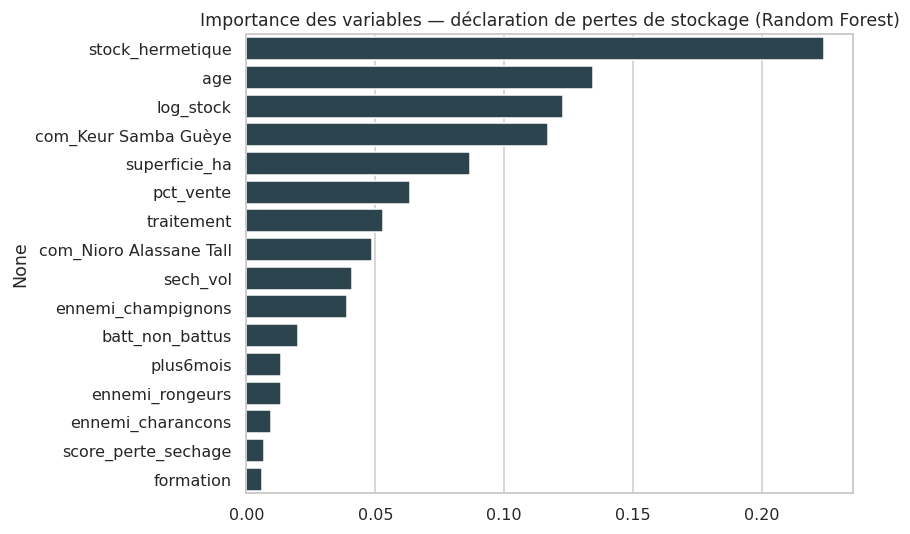

stock_hermetique           0.224
age                        0.135
log_stock                  0.123
com_Keur Samba Guèye       0.117
superficie_ha              0.087
pct_vente                  0.064
traitement                 0.053
com_Nioro Alassane Tall    0.049
sech_vol                   0.041
ennemi_champignons         0.039
batt_non_battus            0.020
plus6mois                  0.014
ennemi_rongeurs            0.013
ennemi_charancons          0.010
score_perte_sechage        0.007
formation                  0.006
dtype: float64

In [33]:
# Importance des variables — Random Forest (validation croisée) pour la déclaration de pertes
feat_cls = ["stock_hermetique", "traitement", "log_stock", "superficie_ha", "age", "formation", "plus6mois", "ennemi_rongeurs", "ennemi_champignons",
            "ennemi_charancons", "sech_vol", "batt_non_battus", "pct_vente", "score_perte_sechage"]
Xc = enq[feat_cls].fillna(enq[feat_cls].median()); Xc = pd.concat([Xc, pd.get_dummies(enq.commune, prefix="com", drop_first=True).astype(int)], axis=1)
yc = enq.pertes_stockage
rf = RandomForestClassifier(n_estimators=500, random_state=0, min_samples_leaf=3, class_weight="balanced")
cv = StratifiedKFold(5, shuffle=True, random_state=0)
print("AUC (validation croisée 5 plis) — RF :", cross_val_score(rf, Xc, yc, cv=cv, scoring="roc_auc").mean().round(3))
print("AUC — régression logistique       :", cross_val_score(LogisticRegression(max_iter=2000), StandardScaler().fit_transform(Xc), yc, cv=cv, scoring="roc_auc").mean().round(3))
rf.fit(Xc, yc)
imp_cls = pd.Series(rf.feature_importances_, index=Xc.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5)); sns.barplot(x=imp_cls.values, y=imp_cls.index, color="#264653"); plt.title("Importance des variables — déclaration de pertes de stockage (Random Forest)")
savefig("08_importance_pertes_declarees")
imp_cls.round(3)

### 8.2 Facteurs de la perte mesurée (fiche de relevé, 192 lots)

In [34]:
poids["log_poids"] = np.log(poids.poids_initial)
poids["decortique"] = (poids.nature == "Décortiqué").astype(int)
# Modèle linéaire (OLS robuste HC3) sur le taux de perte
ols = smf.ols("taux_perte ~ decortique + stockage_hermetique + traite_chimique + log_poids + C(commune)", data=poids).fit(cov_type="HC3")
print(ols.summary().tables[1]); print("R² =", round(ols.rsquared, 3))
# Modèle logistique sur la probabilité de perte. NB : `traite_chimique` provoque une séparation parfaite
# (aucun lot non traité n'a perdu de poids : 0/38 vs 56/154) et ne peut être estimé → il est exclu du logit.
print(pd.crosstab(poids.traite_chimique, poids.perte_positive, margins=True))
logit_p = smf.logit("perte_positive ~ decortique + stockage_hermetique + log_poids", data=poids).fit(disp=0)
pd.DataFrame({"OR": np.exp(logit_p.params), "p": logit_p.pvalues}).round(3)

                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             6.6391      4.392      1.512      0.131      -1.969      15.248
C(commune)[T.Keur Samba Guèye]       -2.1782      2.473     -0.881      0.378      -7.025       2.669
C(commune)[T.Nioro Alassane Tall]    -0.6087      2.471     -0.246      0.805      -5.453       4.235
decortique                            7.7467      1.949      3.975      0.000       3.927      11.566
stockage_hermetique                  -3.8389      1.719     -2.233      0.026      -7.208      -0.470
traite_chimique                      10.4613      1.929      5.424      0.000       6.681      14.241
log_poids                            -1.9415      0.727     -2.672      0.008      -3.366      -0.517
R² = 0.216
perte_positive     0   1  All
traite_chimique              
0          

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,OR,p
Intercept,0.901,0.928
decortique,2.626,0.005
stockage_hermetique,0.000,0.999
log_poids,0.841,0.355


**Interprétation des modèles sur pertes mesurées** (R² OLS = 0,22 ; R² CV Random Forest = 0,55) :
- **Décortiqué** : +7,7 points de perte (p < 0,001) à contenant, traitement, taille et commune constants.
- **Contenant hermétique** : −3,8 points (p = 0,026), effet estimé prudemment car il se cumule avec l'absence de traitement dans ces lots.
- **Traitement chimique** : coefficient **positif** (+10,5 points) — les 38 lots non traités n'ont enregistré aucune perte. Ce résultat ne signifie pas que le traitement provoque des pertes : les lots non traités sont majoritairement des lots en bidon/fût ou des lots « test » de petite taille (médiane 200 kg vs 300–400 kg), suivis de près. Il révèle en revanche que **le traitement chimique en sacs ne protège pas suffisamment** (57 % des lots décortiqués traités aux perles en sac ont perdu du poids).
- **Taille du lot** : les gros lots affichent des taux plus faibles (−1,9 pt par unité de log) — en partie un artefact de résolution des pesées (une perte de 50 kg sur 2 000 kg = 2,5 %).
- L'arbre de décision résume la hiérarchie : *traitement/contenant → nature du produit → taille du lot*.

R² CV (Random Forest) : 0.548
|--- traite_chimique <= 0.50
|   |--- value: [0.00]
|--- traite_chimique >  0.50
|   |--- decortique <= 0.50
|   |   |--- log_poids <= 7.13
|   |   |   |--- value: [4.54]
|   |   |--- log_poids >  7.13
|   |   |   |--- value: [0.00]
|   |--- decortique >  0.50
|   |   |--- log_poids <= 6.44
|   |   |   |--- value: [14.72]
|   |   |--- log_poids >  6.44
|   |   |   |--- value: [5.35]



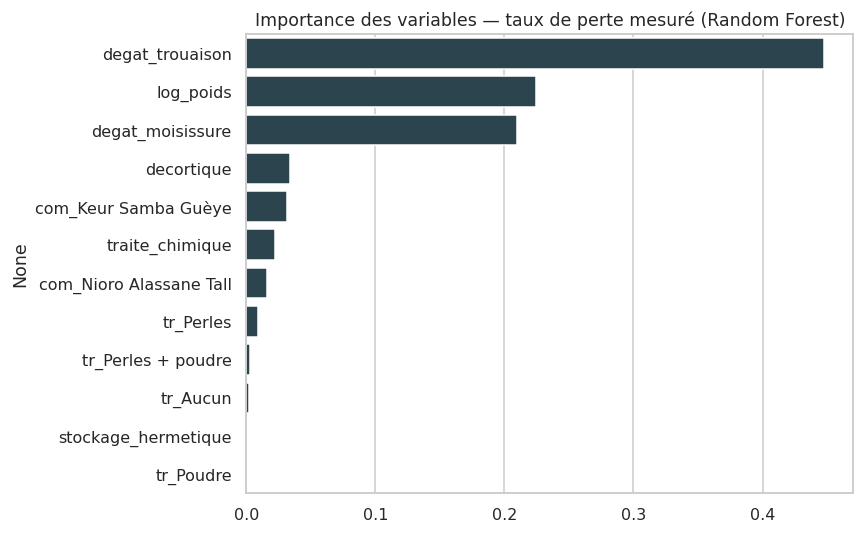

In [35]:
feat_reg = ["decortique", "stockage_hermetique", "traite_chimique", "log_poids", "degat_moisissure", "degat_trouaison"]
Xr = pd.concat([poids[feat_reg], pd.get_dummies(poids.commune, prefix="com", drop_first=True).astype(int), pd.get_dummies(poids.traitement_cat, prefix="tr", drop_first=True).astype(int)], axis=1)
yr = poids.taux_perte
rfr = RandomForestRegressor(n_estimators=500, random_state=0, min_samples_leaf=3).fit(Xr, yr)
print("R² CV (Random Forest) :", cross_val_score(RandomForestRegressor(n_estimators=300, random_state=0, min_samples_leaf=3), Xr, yr, cv=5, scoring="r2").mean().round(3))
imp_reg = pd.Series(rfr.feature_importances_, index=Xr.columns).sort_values(ascending=False)
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=8, random_state=0).fit(poids[["decortique", "stockage_hermetique", "traite_chimique", "log_poids"]], yr)
print(export_text(tree, feature_names=["decortique", "stockage_hermetique", "traite_chimique", "log_poids"]))
plt.figure(figsize=(8, 5)); sns.barplot(x=imp_reg.values, y=imp_reg.index, color="#264653"); plt.title("Importance des variables — taux de perte mesuré (Random Forest)")
savefig("08_importance_pertes_mesurees")

### 8.3 Classement des facteurs déterminants

| Rang | Facteur | Effet sur les pertes | Preuve |
|---|---|---|---|
| 1 | **Contenant hermétique (bidon / fût)** | −10,8 points de perte mesurée sur décortiqué ; OR ≈ 0,1 sur les pertes déclarées | Mann-Whitney p < 1e-4 ; logit p < 0,001 ; 1ʳᵉ importance RF |
| 2 | **Nature du produit stocké** (décortiqué vs gousses) | +4 points | Wilcoxon apparié p = 0,003 |
| 3 | **Type de traitement** (perles + poudre vs perles seules) | −4,6 points sur gousses | Kruskal p = 0,012 ; MW p = 0,007 |
| 4 | **Volume stocké / taille d'exploitation** | Pertes monétaires ↑ avec le stock (ρ = 0,38) ; pas d'effet sur le taux de perte | Spearman p < 1e-5 |
| 5 | Commune | Effet indirect via la diffusion des fûts | χ² p < 0,001 ; non significatif après ajustement |
| – | Traitement chimique oui/non, durée, âge, instruction, formation | Pas d'effet propre démontré | p > 0,05 |

Les dégâts observés (moisissures, trouaison) sont des **symptômes** corrélés aux pertes, pas des causes actionnables — ils ne sont donc pas retenus comme leviers.

---
## ÉTAPE 9 — Segmentation des producteurs (K-Means + ACP)

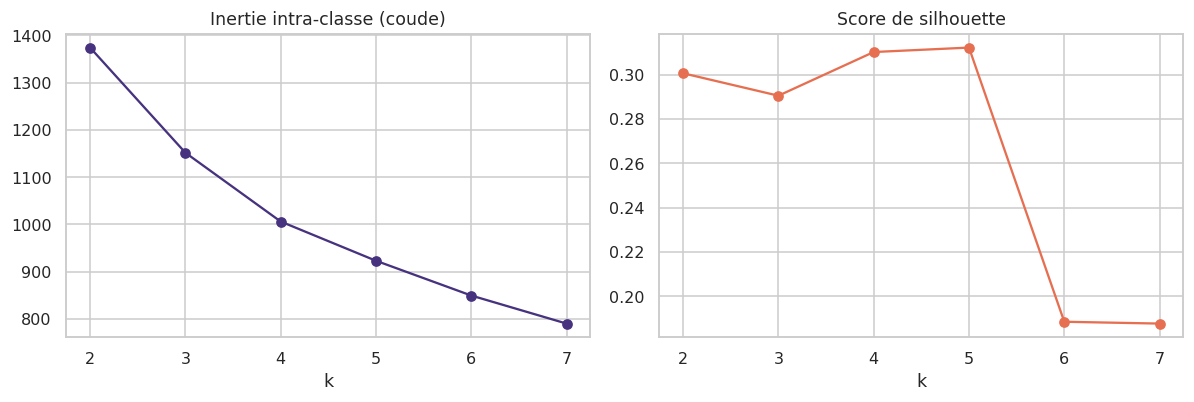

{2: 0.301, 3: 0.291, 4: 0.31, 5: 0.312, 6: 0.188, 7: 0.188}


In [36]:
seg_vars = ["superficie_ha", "production_kg", "qte_stockee_kg", "pct_vente", "valeur_pertes_fcfa", "stock_hermetique", "age", "pertes_stockage", "couverture_alim"]
S = enq[seg_vars].copy()
S["valeur_pertes_fcfa"] = S["valeur_pertes_fcfa"].fillna(0)  # pas de valeur = pas de perte chiffrée
S = S.fillna(S.median())
for c in ["superficie_ha", "production_kg", "qte_stockee_kg", "valeur_pertes_fcfa"]:
    S[c] = np.log1p(S[c])
Z = StandardScaler().fit_transform(S)
sil = {k: silhouette_score(Z, KMeans(k, n_init=20, random_state=0).fit_predict(Z)) for k in range(2, 8)}
inertia = {k: KMeans(k, n_init=20, random_state=0).fit(Z).inertia_ for k in range(2, 8)}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(list(inertia), list(inertia.values()), marker="o"); ax[0].set_title("Inertie intra-classe (coude)"); ax[0].set_xlabel("k")
ax[1].plot(list(sil), list(sil.values()), marker="o", color="#e76f51"); ax[1].set_title("Score de silhouette"); ax[1].set_xlabel("k")
savefig("09_choix_k")
print({k: round(v, 3) for k, v in sil.items()})

In [37]:
K = 4
km = KMeans(K, n_init=50, random_state=0).fit(Z)
enq["segment"] = km.labels_
prof = enq.groupby("segment").agg(n=("id", "size"), age=("age", "mean"), superficie=("superficie_ha", "median"), production=("production_kg", "median"),
                                  rendement=("rendement_kg_ha", "median"), stock=("qte_stockee_kg", "median"), pct_vente=("pct_vente", "mean"),
                                  hermetique=("stock_hermetique", "mean"), pertes_decl=("pertes_stockage", "mean"), valeur_pertes=("valeur_pertes_fcfa", "median"),
                                  couverture=("couverture_alim", "mean"), emprunt=("soudure_emprunt", "mean")).round(2)
# Nommage des segments à partir des profils
def label_seg(r):
    if r.pertes_decl < .3: return "Stockeurs sécurisés"
    if r.superficie >= 4: return "Grands producteurs exposés"
    if r.pct_vente < 30: return "Micro-exploitants d'autoconsommation"
    return "Petits producteurs vulnérables"
prof["libelle"] = prof.apply(label_seg, axis=1)
seg_labels = prof["libelle"].to_dict()
enq["segment_lib"] = enq.segment.map(seg_labels)
prof.set_index("libelle").T

libelle,Grands producteurs exposés,Micro-exploitants d'autoconsommation,Stockeurs sécurisés,Petits producteurs vulnérables
n,26.00,13.00,42.00,114.00
age,54.27,55.08,53.67,51.86
superficie,6.00,1.00,3.00,2.00
production,5000.00,1000.00,1500.00,1500.00
rendement,800.00,500.00,600.00,725.00
stock,2000.00,1000.00,475.00,500.00
pct_vente,65.58,13.08,64.05,67.19
hermetique,0.38,0.46,0.79,0.13
pertes_decl,0.92,1.00,0.00,0.95
valeur_pertes,100000.00,50000.00,7500.00,50000.00


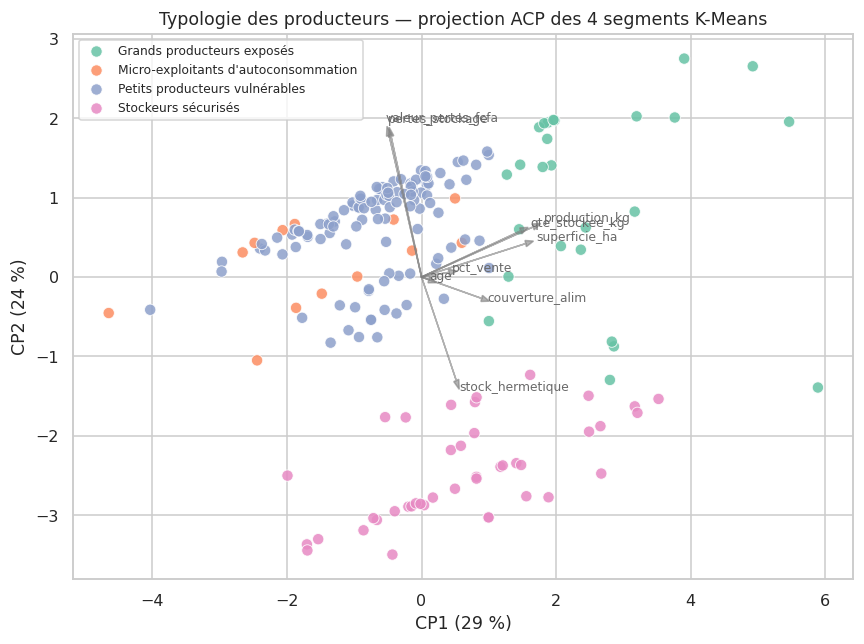

commune,Keur Saloum Diané,Keur Samba Guèye,Nioro Alassane Tall
segment_lib,,,
Grands producteurs exposés,2,7,17
Micro-exploitants d'autoconsommation,1,0,12
Petits producteurs vulnérables,27,38,49
Stockeurs sécurisés,2,31,9


In [38]:
pca = PCA(n_components=2).fit(Z)
pc = pca.transform(Z)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pc[:, 0], y=pc[:, 1], hue=enq.segment_lib, palette="Set2", s=55, alpha=.85)
for i, v in enumerate(seg_vars):
    plt.arrow(0, 0, pca.components_[0, i] * 3, pca.components_[1, i] * 3, color="grey", alpha=.6, head_width=.08)
    plt.text(pca.components_[0, i] * 3.3, pca.components_[1, i] * 3.3, v, fontsize=8, color="dimgrey")
plt.xlabel(f"CP1 ({100*pca.explained_variance_ratio_[0]:.0f} %)"); plt.ylabel(f"CP2 ({100*pca.explained_variance_ratio_[1]:.0f} %)")
plt.title("Typologie des producteurs — projection ACP des 4 segments K-Means"); plt.legend(fontsize=8)
savefig("09_segments_acp")
pd.crosstab(enq.segment_lib, enq.commune)

**Description des segments** (voir tableau de profils ci-dessus) :
- **Stockeurs sécurisés (n = 42, 22 %)** : 3 ha, 79 % utilisent fût/bidon, **aucun ne déclare de pertes**, valeur des pertes quasi nulle, 24 % couvrent l'année, très faible recours à l'emprunt (6 %). Concentrés à Keur Samba Guèye. **Modèle à diffuser.**
- **Grands producteurs exposés (n = 26, 13 %)** : 6 ha, production 5 t, stock 2 t, 66 % vendus, seulement 38 % en hermétique, 92 % déclarent des pertes avec la **valeur la plus élevée (médiane 100 000 FCFA)** ; bonne couverture alimentaire (62 %) grâce au volume. **Enjeu économique majeur** (candidats naturels au warrantage).
- **Petits producteurs vulnérables (n = 114, 58 %)** : 2 ha, 1,5 t, stock 500 kg, 67 % vendus, 13 % en hermétique, 95 % de pertes (≈ 50 000 FCFA), **4 % seulement couvrent l'année**, 19 % empruntent pour la soudure. **Cœur de cible** des interventions (équipement + sécurité alimentaire).
- **Micro-exploitants d'autoconsommation (n = 13, 7 %)** : 1 ha, 1 t, seulement 13 % vendus, 100 % de pertes, 25 % d'emprunt, rendement le plus faible (500 kg/ha). Profil de **grande précarité** nécessitant un appui combiné (semences, fût, crédit soudure).

---
## ÉTAPE 10 — Principaux enseignements et recommandations

### 10.1 Insights clés
1. **Pertes mesurées en stock : 3,8 % (gousses) et 8,0 % (graines décortiquées)** en moyenne par lot ; 5,4 % et 2,2 % en volume pondéré. Un tiers des lots de décortiqué et un quart des lots de gousses sont touchés, avec des pertes allant jusqu'à 33 % (gousses) et 50 % (décortiqué).
2. **Le contenant hermétique (fût / bidon) annule les pertes mesurées** (0 % sur 25 lots) et divise par 10 la probabilité de déclarer des pertes, à traitement et taille constants. C'est le facteur n° 1.
3. **La coque protège** : décortiquer avant stockage double le taux de perte (p = 0,003). Le décortiqué stocké en sac perd 10,8 %.
4. **Le traitement chimique seul ne suffit pas** : appliqué à 85 % des producteurs (perles = phosphure d'aluminium), il ne montre pas d'effet protecteur mesurable une fois le contenant pris en compte ; l'association perles + poudre est en revanche plus efficace sur gousses (1,3 % vs 5,9 %).
5. **Les pertes se creusent entre la 1ʳᵉ et la 2ᵉ pesée** puis plafonnent : la fenêtre critique est le milieu de la saison de stockage (installation des infestations).
6. **Le séchage est l'étape pré-stockage la plus critique** : 90 % jugent ses pertes importantes (pluies tardives, animaux, moisissures — séchage au sol universel) contre 8 % pour le battage.
7. **Impact économique** : 75 % déclarent des pertes de stock ; valeur médiane **50 000 FCFA** (≈ 3 % de la valeur de production ; jusqu'à 500 000 FCFA), corrélée au volume stocké. 95 % disent que les pertes font baisser le prix de vente.
8. **92 % rachètent de l'arachide** (≈ 1 000 FCFA/kg) en cours d'année ; **38 % financent par emprunt/banque** → spirale d'endettement.
9. **Insécurité alimentaire structurelle** : seuls 16 % couvrent l'année ; 83 % achètent au marché pendant la soudure, 14 % empruntent. La taille d'exploitation (≥ 5 ha) est le premier déterminant de la couverture (37 % vs 8–13 %).
10. **Conséquences sociales** pour 63 % : alimentation (98 %), scolarité des enfants (51 %), santé (21 %).
11. **Charge de travail** : 96 % signalent un surcroît de travail (tri, surveillance) qui pèse sur les **femmes dans 97 % des cas**, alors qu'elles ne représentent que 2 % des enquêtés.
12. **Aucun producteur ne connaît ni n'utilise de technologie améliorée** (sacs PICS, silos métalliques…) ; cause unique citée : « pas informé ». 7 % ont reçu une formation.
13. **Keur Samba Guèye** : commune la moins touchée (55 % de pertes déclarées) grâce à 41 % d'usage de fûts/bidons ; **Keur Saloum Diané** la plus vulnérable (petites surfaces, 9 % hermétique, 88 % de pertes).
14. **Rendements faibles et homogènes (≈ 700 kg/ha)**, sans effet d'échelle : le potentiel d'amélioration est agronomique (semences, fertilisation), pas foncier.
15. **Demande spontanée** des producteurs : magasins de stockage (52 %) et fûts de 200 L (34 %), produits de traitement efficaces (23 %) — alignée avec les résultats statistiques.
16. Le lot expérimental « ail » (traitement naturel, n = 5) n'a subi aucune perte : piste à valider sur un échantillon plus large.

### 10.2 Recommandations

**Techniques (stockage)**
- **Priorité 1 — Diffuser le stockage hermétique** : fûts métalliques 200 L / bidons, ou sacs triple-couche (PICS) comme alternative à moindre coût pour le décortiqué et les semences. Objectif : passer de 33 % à > 80 % d'adoption en 3 ans ; commencer par Keur Saloum Diané et les segments « petits vulnérables » et « grands exposés ».
- **Stocker en gousses** et ne décortiquer qu'au moment de la vente / du semis.
- **Combiner fumigant (perles) + insecticide de contact (poudre)** pour les stocks qui restent en sacs, avec formation aux doses et délais de sécurité (le phosphure d'aluminium est dangereux en habitat : plusieurs producteurs demandent un magasin « pour éviter les produits chimiques à la maison »).
- Instaurer un **contrôle de stock à mi-saison** (pesée / inspection à 2–3 mois) : c'est la fenêtre où les pertes s'installent.

**Agronomiques (pré-stockage)**
- Améliorer le **séchage** : séchage sur bâche ou claies surélevées, mise en meule protégée, surveillance contre les animaux ; viser < 8 % d'humidité avant stockage (réduit moisissures et aflatoxines).
- Tri des gousses immatures / cassées avant stockage (réduit les foyers d'infestation).
- Relever les rendements (700 kg/ha) par des semences certifiées et une fertilisation raisonnée : à surface égale, +30 % de production compense largement les pertes post-récolte.

**Économiques**
- **Magasins de stockage villageois** (demande n° 1) couplés au **warrantage** : sécurise le stock, évite la vente précoce à bas prix et le rachat à 1 000 FCFA/kg, réduit le recours à l'emprunt (38 %).
- Subvention / crédit-équipement pour les fûts (coût unitaire faible vs 50 000 FCFA de perte médiane annuelle : retour sur investissement < 1 an).
- Mécanisme de crédit soudure adossé au stock pour les petits producteurs vulnérables.

**Stratégiques**
- Programme d'**information et de formation** (93 % n'ont jamais entendu parler de technologies améliorées) : démonstrations de fûts / sacs PICS au village, ciblant explicitement les **femmes** qui gèrent les stocks.
- Cibler les villages à pertes mesurées > 10 % (Keur Babou Ndity, Simong Bambara, Keur Momath Souna, Touba Mouride).
- Reprendre le protocole de pesée (3 pesées, balance précise, gousses et décortiqué) sur une campagne complète pour construire une référence régionale de pertes.

### 10.3 Limites de l'étude
- Échantillon de convenance (195 producteurs, 3 communes), 98 % d'hommes : pas de représentativité statistique régionale ni du point de vue des femmes.
- Pertes mesurées : pesées à résolution grossière (multiples de 25–50 kg), une seule pesée de suivi pour les gousses, durée de suivi non documentée, lots « test » sélectionnés (biais de sélection sur les non-traités).
- Données déclaratives (production, superficie, valeur des pertes) sujettes à erreurs d'unités et de mémoire ; 6 rendements implausibles exclus.
- Effectifs faibles dans certaines modalités (traitement naturel n = 5, magasins modernes n = 3) limitant la puissance des tests.
- Absence de coordonnées GPS et de dates de mise en stock / pesées → pas de cartographie ni de modèle temporel.

### 10.4 Perspectives
- Essai contrôlé (fût vs sac PICS vs sac + traitement) sur 2 campagnes avec pesées mensuelles et mesure d'humidité et d'aflatoxines.
- Étude complémentaire auprès des femmes (charge de travail, savoir-faire de tri).
- Analyse coût-bénéfice détaillée des options d'équipement et modélisation de l'impact d'un magasin de warrantage sur le revenu.
- Extension géographique (Kaolack, Fatick) et géoréférencement pour cartographie des pertes.

In [39]:
# Export final pour le dashboard et le rapport
enq.to_csv(os.path.join(CLEAN, "enquete_producteurs_clean.csv"), index=False)
poids.to_csv(os.path.join(CLEAN, "releve_poids_clean.csv"), index=False)
prof.to_csv(os.path.join(CLEAN, "profils_segments.csv"))
print("Exports terminés :", os.listdir(CLEAN))

Exports terminés : ['donnees_nettoyees.xlsx', 'resultats_tests_statistiques.xlsx', 'releve_poids_clean.csv', 'enquete_producteurs_clean.csv', 'profils_segments.csv']
